# Emotion Detection from Video using YOLOv8 and CNN

**Two-stage pipeline:** YOLOv8 detects faces; a custom CNN classifies each detected face into one of seven emotions.


## Quick Start: What to Run After a Colab Reconnect

### Standard video demo

1. Have to run **Runtime Setup** immediately below.
2. Have to run **Runtime restore - run after the Setup cell every time Colab reconnects**.
3. Put original videos in `data/test_videos` in Google Drive.
4. Running only the desired batch-processing cell in Section 5 or Section 7.

### API demo

1. Run Runtime Setup.
2. Run the API dependency-install cell in Section 9.
3. Run the API server-start cell in Section 9.
4. Open the printed `/docs` link and use `GET /health` or `POST /process-video`.

### Important safety rule

The Training Archive sections are preserved but are **not part of normal reconnect work**. Never run their training loops unless you intentionally want to train again.


# 1. Runtime Setup

Running the next cell at the start of every new Colab session. It mounts Drive, installs dependencies, and selects GPU or CPU.


In [3]:
#---------Mounting Google Drive and project directory------------

from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/emotion-detection-yolo'

#-------------installing libraries-------------

!pip install ultralytics -q
!pip install opencv-python-headless -q

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import ultralytics
ultralytics.checks()

#---------Checking if gpu or cpu--------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
if device.type == 'cuda':
    !nvidia-smi
else:
    print("WARNING: No GPU detected. Colab free-tier GPU quota may be temporarily exhausted.")
    print("Training will still work on CPU, just slower. You can proceed or wait for GPU to free up.")

Ultralytics 8.4.113 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.0/107.7 GB disk)
Using device: cpu
Training will still work on CPU, just slower. You can proceed or wait for GPU to free up.


# 1.1 Runtime Restore - Normal Reconnect Workflow

After running the Runtime Setup cell, have to run the single code cell below. It restores the trained YOLO and CNN models from Google Drive, the inference preprocessing, confidence-aware `Uncertain` labels, and temporal smoothing.

It **does not train**, overwrite weights, or require the datasets to be downloaded again.


In [4]:
#@title ▶ Runtime restore - run after the Setup cell every time Colab reconnects
# This cell loads saved models only. It never trains or overwrites model weights.

import os
from collections import deque

import cv2
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from ultralytics import YOLO


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        batch_size, channels, _, _ = x.size()
        y = self.avg_pool(x).view(batch_size, channels)
        y = self.fc(y).view(batch_size, channels, 1, 1)
        return x * y.expand_as(x)


class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1); self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1); self.bn2 = nn.BatchNorm2d(64)
        self.se2 = SEBlock(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1); self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1); self.bn4 = nn.BatchNorm2d(256)
        self.se4 = SEBlock(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.4)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.se2(x)
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.se4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)


# Load saved weights from Drive. No training is performed here.

face_model = YOLO(f"{PROJECT_ROOT}/models/face_detector/yolov8n_face/weights/best.pt")

emotion_model = EmotionCNN(num_classes=7).to(device)
checkpoint = torch.load(
    f"{PROJECT_ROOT}/models/emotion_classifier/best_emotion_model.pt",
    map_location=device,
)
emotion_model.load_state_dict(checkpoint["model_state_dict"])
emotion_model.eval()

emotion_names = {
    0: "Angry", 1: "Disgust", 2: "Fear", 3: "Happy",
    4: "Sad", 5: "Surprise", 6: "Neutral",
}

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

INPUT_VIDEO_DIR = f"{PROJECT_ROOT}/data/test_videos"
OUTPUT_VIDEO_DIR = f"{PROJECT_ROOT}/outputs/videos"
UNCERTAIN_OUTPUT_DIR = f"{OUTPUT_VIDEO_DIR}/batch_results_with_uncertain"
SMOOTHED_OUTPUT_DIR = f"{OUTPUT_VIDEO_DIR}/batch_results_smoothed"

for folder in [INPUT_VIDEO_DIR, OUTPUT_VIDEO_DIR, UNCERTAIN_OUTPUT_DIR, SMOOTHED_OUTPUT_DIR]:
    os.makedirs(folder, exist_ok=True)

EMOTION_CONFIDENCE_THRESHOLD = 45.0
SMOOTHING_WINDOW = 5
TRACK_IOU_THRESHOLD = 0.30
TRACK_MAX_MISSING_FRAMES = 15
face_tracks = {}
next_track_id = 1
video_frame_index = 0


def calculate_iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    intersection = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = (max(0, ax2 - ax1) * max(0, ay2 - ay1) +
             max(0, bx2 - bx1) * max(0, by2 - by1) - intersection)
    return intersection / union if union else 0.0


def predict_emotion_probabilities(face_bgr):
    gray_face = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
    gray_face = cv2.resize(gray_face, (48, 48))
    tensor = val_transform(Image.fromarray(gray_face)).unsqueeze(0).to(device)
    with torch.no_grad():
        return torch.softmax(emotion_model(tensor), dim=1)[0].cpu().numpy()


def get_track_id(current_box, used_track_ids):
    global next_track_id
    best_track_id, best_iou = None, 0.0
    for track_id, track in face_tracks.items():
        if track_id in used_track_ids:
            continue
        overlap = calculate_iou(current_box, track["last_box"])
        if overlap > best_iou:
            best_track_id, best_iou = track_id, overlap
    if best_track_id is not None and best_iou >= TRACK_IOU_THRESHOLD:
        return best_track_id
    track_id = next_track_id
    next_track_id += 1
    face_tracks[track_id] = {
        "last_box": current_box,
        "probability_history": deque(maxlen=SMOOTHING_WINDOW),
        "last_seen_frame": video_frame_index,
    }
    return track_id


def process_frame(frame, face_confidence=0.40):
    """YOLO face detection + CNN prediction + uncertainty + temporal smoothing."""
    global video_frame_index
    output_frame = frame.copy()
    result = face_model.predict(source=frame, conf=face_confidence, imgsz=640, verbose=False)[0]
    used_track_ids = set()
    face_count = 0

    if result.boxes is not None:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(frame.shape[1], x2), min(frame.shape[0], y2)
            face_crop = frame[y1:y2, x1:x2]
            if face_crop.size == 0 or face_crop.shape[0] < 20 or face_crop.shape[1] < 20:
                continue

            current_box = [x1, y1, x2, y2]
            track_id = get_track_id(current_box, used_track_ids)
            used_track_ids.add(track_id)
            track = face_tracks[track_id]
            track["last_box"] = current_box
            track["last_seen_frame"] = video_frame_index
            track["probability_history"].append(predict_emotion_probabilities(face_crop))

            smoothed_probabilities = np.mean(np.stack(track["probability_history"]), axis=0)
            emotion_id = int(np.argmax(smoothed_probabilities))
            confidence = float(smoothed_probabilities[emotion_id] * 100)
            is_uncertain = confidence < EMOTION_CONFIDENCE_THRESHOLD
            label = "Uncertain" if is_uncertain else emotion_names[emotion_id]
            colour = (0, 165, 255) if is_uncertain else (0, 255, 0)

            cv2.rectangle(output_frame, (x1, y1), (x2, y2), colour, 2)
            cv2.putText(
                output_frame,
                f"{label} ({confidence:.1f}%)",
                (x1, max(y1 - 10, 25)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                colour,
                2,
                cv2.LINE_AA,
            )
            face_count += 1

    for track_id in [
        track_id for track_id, track in face_tracks.items()
        if video_frame_index - track["last_seen_frame"] > TRACK_MAX_MISSING_FRAMES
    ]:
        del face_tracks[track_id]

    video_frame_index += 1
    return output_frame, face_count


print("Runtime ready.")
print("Loaded: trained YOLO face detector + trained CNN emotion classifier")
print(f"Device: {device}")
print("Enabled: 45% uncertainty threshold + 5-frame temporal smoothing")


Runtime ready.
Loaded: trained YOLO face detector + trained CNN emotion classifier
Device: cpu
Enabled: 45% uncertainty threshold + 5-frame temporal smoothing


# 2. Training Archive - YOLOv8 Face Detector

> **Do not run this section unless you intentionally want to repeat training.**
> All cells are preserved for reproducibility. Saved YOLO weights are loaded by the runtime-restore cell above.


**2.1 Download both the datasets from Kaggle**

In [ ]:
yaml_content = f"""train: /content/wider_face_local/images/train
val: /content/wider_face_local/images/val

nc: 1
names: ['face']
"""

with open('/content/wider_face_local/data.yaml', 'w') as f:
    f.write(yaml_content)

print("data.yaml created:")
print(yaml_content)

**Folder Setup in drive**

In [ ]:
# Creating the project folder structure

import os
PROJECT_ROOT = '/content/drive/MyDrive/emotion-detection-yolo'
folders = [
    'data/wider_face', 'data/fer2013',
    'models/face_detector', 'models/emotion_classifier',
    'src', 'outputs/videos', 'outputs/checkpoints'
]
for f in folders:
    os.makedirs(os.path.join(PROJECT_ROOT, f), exist_ok=True)
print("Ready at:", PROJECT_ROOT)

Ready at: /content/drive/MyDrive/emotion-detection-yolo


In [ ]:
# Connecting Kaggle API
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

**Downloading FER dataset from Kaggle**

In [ ]:
PROJECT_ROOT = '/content/drive/MyDrive/emotion-detection-yolo'

!kaggle datasets download -d astraszab/facial-expression-dataset-image-folders-fer2013 -p {PROJECT_ROOT}/data/fer2013

Dataset URL: https://www.kaggle.com/datasets/astraszab/facial-expression-dataset-image-folders-fer2013
License(s): unknown
User cancelled operation


In [ ]:
!rm -rf {PROJECT_ROOT}/data/fer2013/data
!rm -rf {PROJECT_ROOT}/data/fer2013/test
!rm -rf {PROJECT_ROOT}/data/fer2013/train

^C


In [ ]:
!unzip -q "{PROJECT_ROOT}/data/fer2013/facial-expression-dataset-image-folders-fer2013.zip" -d /content/fer2013_local
!ls /content/fer2013_local

ls: cannot access '/content/fer2013_local': No such file or directory


In [ ]:
!cp -r /content/fer2013_local/* {PROJECT_ROOT}/data/fer2013/
!ls {PROJECT_ROOT}/data/fer2013

cp: cannot stat '/content/fer2013_local/*': No such file or directory
data  facial-expression-dataset-image-folders-fer2013.zip


In [ ]:
!ls {PROJECT_ROOT}/data/fer2013/data

test  train  val


In [ ]:
!ls {PROJECT_ROOT}/data/fer2013/data/train

0  1  2  3  4  5  6


In [ ]:
from IPython.testing import test
import os
train_path = f'{PROJECT_ROOT}/data/fer2013/data/train'
for emotion in os.listdir(train_path):
    count = len(os.listdir(os.path.join(train_path, emotion)))
    print(f"{emotion}: {count} images")

KeyboardInterrupt: 

**Downloading Wider Face Dataset**

In [ ]:
!kaggle datasets list -s "wider face"

ref                                                             title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -----------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
mksaad/wider-face-a-face-detection-benchmark                    WIDER FACE                                        3662993623  2019-01-05 14:07:49.930000           5912         83  0.4375           
lylmsc/wider-face-for-yolo-training                             WIDER FACE for YOLO training                      2631346299  2023-05-22 08:00:58.393000           2354         17  0.875            
canomercik/wider-face-dataset-for-yolov12-format                WIDER Face Dataset for YOLO12                     3685362154  2025-03-11 17:06:14.727000            725         13  1                
thedevasta

In [ ]:
!kaggle datasets download -d lylmsc/wider-face-for-yolo-training -p {PROJECT_ROOT}/data/wider_face

Dataset URL: https://www.kaggle.com/datasets/lylmsc/wider-face-for-yolo-training
License(s): CC0-1.0
100% 2.45G/2.45G [00:36<00:00, 72.1MB/s]



In [ ]:
!unzip -q "{PROJECT_ROOT}/data/wider_face/wider-face-for-yolo-training.zip" -d /content/wider_face_local
!ls /content/wider_face_local

images	labels


In [ ]:
!rsync -ah --info=progress2 /content/wider_face_local/ {PROJECT_ROOT}/data/wider_face/
!ls {PROJECT_ROOT}/data/wider_face

          2.76G 100%    4.61MB/s    0:09:30 (xfr#25760, to-chk=0/25763)
images	labels	wider-face-for-yolo-training.zip


In [ ]:
!ls -la {PROJECT_ROOT}/data/wider_face

total 2569683
drwx------ 2 root root       4096 Jul 28 13:15 images
drwx------ 2 root root       4096 Jul 28 13:15 labels
-rw------- 1 root root 2631346299 May 22  2023 wider-face-for-yolo-training.zip


In [ ]:
!ls {PROJECT_ROOT}/data/wider_face/images | head -5
!echo "---"
!ls {PROJECT_ROOT}/data/wider_face/labels | head -5
!echo "---"
!find {PROJECT_ROOT}/data/wider_face/images -type f | wc -l
!find {PROJECT_ROOT}/data/wider_face/labels -type f | wc -l

wider_0.jpg
wider_10000.jpg
wider_10001.jpg
wider_10002.jpg
wider_10003.jpg
---
wider_0.txt
wider_10000.txt
wider_10001.txt
wider_10002.txt
wider_10003.txt
---
12880
12880


**Inspection of Wider face dataset if it is compatabile with YOLO**

In [ ]:
import os

WIDER_ROOT = f'{PROJECT_ROOT}/data/wider_face'
print("Top level:", os.listdir(WIDER_ROOT))
print("Inside images/:", os.listdir(f'{WIDER_ROOT}/images')[:10])
print("Inside labels/:", os.listdir(f'{WIDER_ROOT}/labels')[:10])

Top level: ['wider-face-for-yolo-training.zip', 'images', 'labels']
Inside images/: ['wider_10609.jpg', 'wider_1061.jpg', 'wider_10610.jpg', 'wider_10611.jpg', 'wider_10612.jpg', 'wider_10613.jpg', 'wider_10614.jpg', 'wider_10615.jpg', 'wider_10616.jpg', 'wider_10617.jpg']
Inside labels/: []


In [ ]:
WIDER_ROOT_LOCAL = '/content/wider_face_local'

print("Total images:", count_files(f'{WIDER_ROOT_LOCAL}/images'))
print("Total labels:", count_files(f'{WIDER_ROOT_LOCAL}/labels'))

Total images: 12880
Total labels: 12880


In [ ]:
import glob

sample_label_files = glob.glob('/content/wider_face_local/labels/**/*.txt', recursive=True)
print("Found", len(sample_label_files), "label files")
print("Example path:", sample_label_files[0])

with open(sample_label_files[0], 'r') as f:
    print("Contents:")
    print(f.read())

Found 12880 label files
Example path: /content/wider_face_local/labels/wider_7916.txt
Contents:
0 0.408203125 0.30385487528344673 0.09375 0.14512471655328799
0 0.71875 0.6473922902494331 0.0625 0.09750566893424037



**2.2 Splitting data into train/val - locally**
- Zipping it and  storing in drive and setting the dataset into correct folder

In [ ]:
import os

LOCAL_ROOT = '/content/wider_face_local'

def move_back(split_name):
    img_dir = f'{LOCAL_ROOT}/images/{split_name}'
    lbl_dir = f'{LOCAL_ROOT}/labels/{split_name}'
    count = 0
    for fname in os.listdir(img_dir):
        os.rename(f'{img_dir}/{fname}', f'{LOCAL_ROOT}/images/{fname}')
        count += 1
    for fname in os.listdir(lbl_dir):
        os.rename(f'{lbl_dir}/{fname}', f'{LOCAL_ROOT}/labels/{fname}')
    return count

train_back = move_back('train')
val_back = move_back('val')
print(f"Moved back from train: {train_back}, from val: {val_back}")

print("Flat images now:", len([f for f in os.listdir(f'{LOCAL_ROOT}/images') if f.endswith('.jpg')]))
print("Flat labels now:", len([f for f in os.listdir(f'{LOCAL_ROOT}/labels') if f.endswith('.txt')]))

Moved back from train: 11592, from val: 1288
Flat images now: 12880
Flat labels now: 12880


In [ ]:
import random

random.seed(42)

for split in ['train', 'val']:
    os.makedirs(f'{LOCAL_ROOT}/images/{split}', exist_ok=True)
    os.makedirs(f'{LOCAL_ROOT}/labels/{split}', exist_ok=True)

image_files = [f for f in os.listdir(f'{LOCAL_ROOT}/images') if f.endswith('.jpg')]
random.shuffle(image_files)

split_idx = int(len(image_files) * 0.8)   # <-- changed from 0.9 to 0.8
train_files = image_files[:split_idx]
val_files = image_files[split_idx:]
print(f"Will move to train: {len(train_files)}, Will move to val: {len(val_files)}")

def move_split(file_list, split_name):
    moved = 0
    for fname in file_list:
        base = fname.replace('.jpg', '')
        src_img = f'{LOCAL_ROOT}/images/{fname}'
        dst_img = f'{LOCAL_ROOT}/images/{split_name}/{fname}'
        src_lbl = f'{LOCAL_ROOT}/labels/{base}.txt'
        dst_lbl = f'{LOCAL_ROOT}/labels/{split_name}/{base}.txt'
        if os.path.exists(src_img) and os.path.exists(src_lbl):
            os.rename(src_img, dst_img)
            os.rename(src_lbl, dst_lbl)
            moved += 1
    return moved

train_moved = move_split(train_files, 'train')
val_moved = move_split(val_files, 'val')
print(f"Moved to train: {train_moved}, Moved to val: {val_moved}")

print("\n--- Final counts ---")
print("Train images:", len(os.listdir(f'{LOCAL_ROOT}/images/train')))
print("Val images:", len(os.listdir(f'{LOCAL_ROOT}/images/val')))

Will move to train: 10304, Will move to val: 2576
Moved to train: 10304, Moved to val: 2576

--- Final counts ---
Train images: 10304
Val images: 2576


**zip this final split version and save to Drive (one-time, replaces old zip)**

In [ ]:
!zip -rq /content/wider_face_split.zip /content/wider_face_local
!ls -lh /content/wider_face_split.zip

-rw-r--r-- 1 root root 2.5G Jul 29 07:14 /content/wider_face_split.zip


In [ ]:
!cp /content/wider_face_split.zip {PROJECT_ROOT}/data/wider_face/
!rm {PROJECT_ROOT}/data/wider_face/wider_face_verified.zip
!ls -lh {PROJECT_ROOT}/data/wider_face

total 2.5G
-rw------- 1 root root 2.5G Jul 29 07:16 wider_face_split.zip


**CREATING YAML FILE**

In [ ]:
yaml_content = f"""train: /content/wider_face_local/images/train
val: /content/wider_face_local/images/val

nc: 1
names: ['face']
"""

with open('/content/wider_face_local/data.yaml', 'w') as f:
    f.write(yaml_content)

print("data.yaml created:")
print(yaml_content)

data.yaml created:
train: /content/wider_face_local/images/train
val: /content/wider_face_local/images/val

nc: 1
names: ['face']



**2.3 Using Pretrained YOLOv8n model and fine-tuning**

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/wider_face_local/data.yaml',
    epochs=30,
    imgsz=640,
    batch=16,
    project=f'{PROJECT_ROOT}/models/face_detector',
    name='yolov8n_face',
    patience=10,
    hsv_h=0.015,      # slight hue variation - simulates different skin tones/lighting color casts
    hsv_v=0.4,        # brightness variation - directly targets "lighting" robustness
    fliplr=0.5,       # horizontal flip - faces work fine mirrored, doubles effective variety
    mosaic=1.0,       # combines 4 images into one during training - helps with small/partial faces (occlusion-like scenarios)
    degrees=5.0,      # slight rotation - handles tilted heads
    close_mosaic=10   # disable mosaic augmentation for the last 10 epochs
)

Ultralytics 8.4.110 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/wider_face_local/data.yaml, degrees=5.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_face, nbs=64, nms=

In [ ]:
from ultralytics import YOLO
from PIL import Image

# Load our fine-tuned face detector (not the generic yolov8n.pt anymore - our trained version)
face_model = YOLO(f'{PROJECT_ROOT}/models/face_detector/yolov8n_face/weights/best.pt')

print("Model loaded successfully")
print("Classes:", face_model.names)  # should show {0: 'face'}

Model loaded successfully
Classes: {0: 'face'}


**Testing an image from phone to see how much accurate is the model**

In [ ]:
from google.colab import files
uploaded = files.upload()  # click "Choose Files" and select this photo from your device

KeyboardInterrupt: 

In [ ]:
# Running detection
import glob

# Get the filename we just uploaded (assumes only one file uploaded)
uploaded_filename = list(uploaded.keys())[0]
print("Uploaded:", uploaded_filename)

# Run our fine-tuned face detector on it
results = face_model.predict(source=uploaded_filename, conf=0.4, save=True)

# Print how many faces it found
for r in results:
    print(f"Faces detected: {len(r.boxes)}")

In [ ]:
import os

save_dir = results[0].save_dir
print("Save directory:", save_dir)
print("Files inside:", os.listdir(save_dir))

In [ ]:
import os
from PIL import Image

save_dir = results[0].save_dir
actual_files = os.listdir(save_dir)
print("Files found:", actual_files)

img_path = os.path.join(save_dir, actual_files[0])
print("Opening:", img_path)

# Display inline
img = Image.open(img_path)
display(img)

# Save a permanent copy to Drive (outputs folder we created back in Phase 0)
drive_save_path = f'{PROJECT_ROOT}/outputs/videos/face_detection_test1.jpg'
img.save(drive_save_path)
print("Saved permanently to:", drive_save_path)

# 3. Training Archive - CNN Emotion Classifier

> **Do not run this section unless you intentionally want to repeat CNN training.**
> All training cells are retained so the work is reproducible. Saved CNN weights are loaded by the runtime-restore cell above.


**Visually inspect FER-2013 samples**

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

FER2013_PATH = f'{PROJECT_ROOT}/data/fer2013/data/train'
emotion_names = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

fig, axes = plt.subplots(1, 7, figsize=(18, 3))

for i, (class_id, name) in enumerate(emotion_names.items()):
    class_folder = f'{FER2013_PATH}/{class_id}'
    sample_file = os.listdir(class_folder)[0]
    img = Image.open(f'{class_folder}/{sample_file}')
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Verify real counts in Drive right now

In [ ]:
for split in ['train', 'val', 'test']:
    split_path = f'{LOCAL_FER_ROOT}/data/{split}'
    print(f"\n{split}:")
    total = 0
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        count = len(os.listdir(cls_path))
        total += count
        print(f"  class {cls}: {count}")
    print(f"  TOTAL: {total}")

**DataLoaders**

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

LOCAL_FER_DATA = f'{LOCAL_FER_ROOT}/data'

train_dataset = datasets.ImageFolder(f'{LOCAL_FER_DATA}/train', transform=train_transform)
val_dataset = datasets.ImageFolder(f'{LOCAL_FER_DATA}/val', transform=val_transform)
test_dataset = datasets.ImageFolder(f'{LOCAL_FER_DATA}/test', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Class mapping: {train_dataset.class_to_idx}")

**Class Weights**

In [ ]:
import torch
import collections

train_targets = [label for _, label in train_dataset.samples]
class_counts = collections.Counter(train_targets)
total_samples = len(train_dataset)
num_classes = len(class_counts)

weights = [total_samples / (num_classes * class_counts[i]) for i in range(num_classes)]
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

**CNN Model with SE Attention Block**

In [3]:
import torch.nn as nn

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1); self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1); self.bn2 = nn.BatchNorm2d(64)
        self.se2 = SEBlock(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1); self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1); self.bn4 = nn.BatchNorm2d(256)
        self.se4 = SEBlock(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.4)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.se2(x)
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.se4(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

model = EmotionCNN(7).to(device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 440,007


**Weighted Focal Loss**

In [ ]:
import torch.nn.functional as F

class WeightedFocalLoss(nn.Module):
    def __init__(self, class_weights, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.class_weights = class_weights
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs, targets,
            weight=self.class_weights,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )
        pt = torch.exp(-ce_loss)
        focal_term = (1 - pt) ** self.gamma
        return (focal_term * ce_loss).mean()

criterion = WeightedFocalLoss(class_weights, gamma=2.0, label_smoothing=0.1)
print("Weighted Focal Loss ready.")

**Training loop (with checkpoint resume + early stopping)**

In [ ]:
import torch.optim as optim
import time

SAVE_DIR = f'{PROJECT_ROOT}/models/emotion_classifier'
os.makedirs(SAVE_DIR, exist_ok=True)
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'best_emotion_model.pt')

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

start_epoch = 0
best_val_loss = float('inf')
epochs_no_improve = 0
EARLY_STOP_PATIENCE = 7

if os.path.exists(MODEL_SAVE_PATH):
    checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    best_val_loss = checkpoint['val_loss']
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming from epoch {start_epoch + 1}, best val loss: {best_val_loss:.4f}")
else:
    print("Starting fresh training.")

EPOCHS = 40
total_batches = len(train_loader)
print(f"Total batches per epoch: {total_batches}")

for epoch in range(start_epoch, EPOCHS):
    start_time = time.time()
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        train_total += labels.size(0)
        train_correct += preds.eq(labels).sum().item()

        # Print progress every 50 batches so we can SEE it's alive
        if (batch_idx + 1) % 50 == 0:
            elapsed_so_far = time.time() - start_time
            print(f"  Epoch {epoch+1}, Batch {batch_idx+1}/{total_batches} "
                  f"| Running loss: {train_loss/train_total:.4f} | Elapsed: {elapsed_so_far:.1f}s")

    epoch_train_loss = train_loss / len(train_dataset)
    epoch_train_acc = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            val_total += labels.size(0)
            val_correct += preds.eq(labels).sum().item()

    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = val_correct / val_total
    scheduler.step(epoch_val_loss)
    elapsed = time.time() - start_time

    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc*100:.2f}% | Time: {elapsed:.1f}s")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss, 'val_acc': epoch_val_acc,
            'class_mapping': train_dataset.class_to_idx
        }, MODEL_SAVE_PATH)
        print(f"    --> Saved best model")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping triggered.")
            break

print("\nTraining completed!")

**Loading trained emotional weights, opening colab every time**

In [4]:
emotion_model = EmotionCNN(num_classes=7).to(device)
checkpoint = torch.load(f'{PROJECT_ROOT}/models/emotion_classifier/best_emotion_model.pt', map_location=device)
emotion_model.load_state_dict(checkpoint['model_state_dict'])
emotion_model.eval()

emotion_names = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}
print("Emotion classifier loaded successfully")
print(f"Best validation accuracy achieved: {checkpoint['val_acc']*100:.2f}%")
print(f"Best validation loss: {checkpoint['val_loss']:.4f}")

Emotion classifier loaded successfully
Best validation accuracy achieved: 62.83%
Best validation loss: 0.9487


## 4. Runtime Inference Components

The following original cells show the individual loading and integration steps. For a normal reconnect, use the single **Runtime restore** cell near the top instead.


In [5]:
from torchvision import transforms

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

print("CNN inference preprocessing restored.")

CNN inference preprocessing restored.


**Integrate trained YOLO face detector with CNN emotion model**

In [6]:
import cv2
import numpy as np
import torch
from PIL import Image

# Your existing notebook already defines:
# face_model      -> trained YOLO face detector
# emotion_model   -> trained PyTorch CNN
# val_transform   -> grayscale + ToTensor + Normalize([0.5], [0.5])
# emotion_names   -> correct FER-2013 class mapping

emotion_model.eval()

def predict_emotion(face_bgr):
    """
    Takes one face crop from YOLO (BGR OpenCV image)
    and returns: emotion label, confidence percentage.
    """

    # FER-2013 and your CNN use 48x48 grayscale face images
    gray_face = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
    gray_face = cv2.resize(gray_face, (48, 48))

    # Convert to PIL because val_transform expects a PIL image.
    # val_transform applies:
    # ToTensor() and Normalize(mean=[0.5], std=[0.5])
    face_pil = Image.fromarray(gray_face)
    face_tensor = val_transform(face_pil).unsqueeze(0).to(device)

    # CNN inference
    with torch.no_grad():
        logits = emotion_model(face_tensor)
        probabilities = torch.softmax(logits, dim=1)[0]

        emotion_id = int(torch.argmax(probabilities).item())
        confidence = float(probabilities[emotion_id].item() * 100)

    return emotion_names[emotion_id], confidence


def process_frame(frame, face_confidence=0.40):
    """
    Runs the complete pipeline for one video frame:
    1. YOLO detects all faces.
    2. Each face is cropped.
    3. CNN predicts its emotion.
    4. Bounding box + emotion are drawn on the frame.
    """

    output_frame = frame.copy()

    # YOLO face detection
    yolo_results = face_model.predict(
        source=frame,
        conf=face_confidence,
        imgsz=640,
        verbose=False
    )

    result = yolo_results[0]

    # No face detected
    if result.boxes is None or len(result.boxes) == 0:
        return output_frame, 0

    face_count = 0

    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        detection_conf = float(box.conf[0].cpu().numpy())

        # Keep coordinates within the video frame
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(frame.shape[1], x2)
        y2 = min(frame.shape[0], y2)

        # Extract the detected face
        face_crop = frame[y1:y2, x1:x2]

        # Ignore an invalid or very small face crop
        if face_crop.size == 0 or face_crop.shape[0] < 20 or face_crop.shape[1] < 20:
            continue

        # CNN emotion classification
        emotion, emotion_conf = predict_emotion(face_crop)
        face_count += 1

        # Draw YOLO face bounding box
        cv2.rectangle(output_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Label includes CNN emotion confidence
        label = f"{emotion} ({emotion_conf:.1f}%)"

        # Background rectangle for readable text
        label_y = max(y1 - 10, 25)
        cv2.putText(
            output_frame,
            label,
            (x1, label_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )

    return output_frame, face_count


print("Pipeline functions are ready.")
print("YOLO: face detection | CNN: emotion classification")

Pipeline functions are ready.
YOLO: face detection | CNN: emotion classification


# 5. Video Processing and Batch Demonstrations

Use this section to create annotated output videos from files placed in `data/test_videos`.


In [7]:
# Create permanent Drive folders for input and output videos

import os

INPUT_VIDEO_DIR = f"{PROJECT_ROOT}/data/test_videos"
OUTPUT_VIDEO_DIR = f"{PROJECT_ROOT}/outputs/videos"

os.makedirs(INPUT_VIDEO_DIR, exist_ok=True)
os.makedirs(OUTPUT_VIDEO_DIR, exist_ok=True)

print("Put your original test video here:")
print(INPUT_VIDEO_DIR)

print("\nProcessed emotion-detection videos will be saved here:")
print(OUTPUT_VIDEO_DIR)

Put your original test video here:
/content/drive/MyDrive/emotion-detection-yolo/data/test_videos

Processed emotion-detection videos will be saved here:
/content/drive/MyDrive/emotion-detection-yolo/outputs/videos


In [ ]:
# Process the real video with YOLO face detection + CNN emotion detection

import os
import glob
import time
import cv2

# Find the video you placed in data/test_videos
video_files = (
    glob.glob(f"{INPUT_VIDEO_DIR}/*.mp4") +
    glob.glob(f"{INPUT_VIDEO_DIR}/*.avi") +
    glob.glob(f"{INPUT_VIDEO_DIR}/*.mov")
)

if len(video_files) == 0:
    raise FileNotFoundError(f"No video found in: {INPUT_VIDEO_DIR}")

if len(video_files) > 1:
    raise ValueError(f"More than one video found. Keep only one test video for now:\n{video_files}")

INPUT_VIDEO_PATH = video_files[0]

# Output name: emotion_<your-original-video-name>.mp4
video_name = os.path.splitext(os.path.basename(INPUT_VIDEO_PATH))[0]
OUTPUT_VIDEO_PATH = f"{OUTPUT_VIDEO_DIR}/emotion_{video_name}.mp4"

# Open input video
cap = cv2.VideoCapture(INPUT_VIDEO_PATH)

if not cap.isOpened():
    raise ValueError(f"Cannot open video: {INPUT_VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Create output video writer
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(
    OUTPUT_VIDEO_PATH,
    fourcc,
    fps,
    (frame_width, frame_height)
)

print("Input video:", INPUT_VIDEO_PATH)
print("Output video:", OUTPUT_VIDEO_PATH)
print(f"Video details: {frame_width}x{frame_height}, {fps:.2f} FPS, {total_frames} frames")

frame_number = 0
start_time = time.time()

while True:
    success, frame = cap.read()

    if not success:
        break

    # Runs: YOLO face detection -> face crop -> CNN emotion prediction
    processed_frame, face_count = process_frame(frame, face_confidence=0.40)

    # Save the annotated frame
    out.write(processed_frame)

    frame_number += 1

    if frame_number % 30 == 0:
        elapsed = time.time() - start_time
        current_fps = frame_number / elapsed
        print(
            f"Processed {frame_number}/{total_frames} frames | "
            f"Faces in current frame: {face_count} | "
            f"Pipeline speed: {current_fps:.2f} FPS"
        )

cap.release()
out.release()

elapsed_time = time.time() - start_time
pipeline_fps = frame_number / elapsed_time

print("\nProcessing completed.")
print(f"Total frames processed: {frame_number}")
print(f"Total processing time: {elapsed_time:.2f} seconds")
print(f"End-to-end pipeline FPS: {pipeline_fps:.2f}")
print(f"\nResult saved in Drive:\n{OUTPUT_VIDEO_PATH}")

Input video: /content/drive/MyDrive/emotion-detection-yolo/data/test_videos/test video1.mp4
Output video: /content/drive/MyDrive/emotion-detection-yolo/outputs/videos/emotion_test video1.mp4
Video details: 1024x576, 29.98 FPS, 1298 frames
Processed 30/1298 frames | Faces in current frame: 4 | Pipeline speed: 21.45 FPS
Processed 60/1298 frames | Faces in current frame: 3 | Pipeline speed: 27.78 FPS
Processed 90/1298 frames | Faces in current frame: 3 | Pipeline speed: 31.29 FPS
Processed 120/1298 frames | Faces in current frame: 4 | Pipeline speed: 33.16 FPS
Processed 150/1298 frames | Faces in current frame: 4 | Pipeline speed: 34.10 FPS
Processed 180/1298 frames | Faces in current frame: 3 | Pipeline speed: 35.12 FPS
Processed 210/1298 frames | Faces in current frame: 2 | Pipeline speed: 36.25 FPS
Processed 240/1298 frames | Faces in current frame: 4 | Pipeline speed: 36.51 FPS
Processed 270/1298 frames | Faces in current frame: 4 | Pipeline speed: 36.52 FPS
Processed 300/1298 frames 

In [ ]:
# Verify, preview, and download the completed output video

import os
import shutil
import cv2
from IPython.display import Video, display
from google.colab import files

# Copy the completed Drive video to Colab local storage
LOCAL_OUTPUT_VIDEO = f"/content/{os.path.basename(OUTPUT_VIDEO_PATH)}"

shutil.copy2(OUTPUT_VIDEO_PATH, LOCAL_OUTPUT_VIDEO)

# Verify that OpenCV can read the local copy
check_video = cv2.VideoCapture(LOCAL_OUTPUT_VIDEO)

if not check_video.isOpened():
    raise RuntimeError("The output video could not be opened. Do not delete it; tell me this message.")

output_frames = int(check_video.get(cv2.CAP_PROP_FRAME_COUNT))
output_fps = check_video.get(cv2.CAP_PROP_FPS)
output_width = int(check_video.get(cv2.CAP_PROP_FRAME_WIDTH))
output_height = int(check_video.get(cv2.CAP_PROP_FRAME_HEIGHT))

check_video.release()

print("Output video verified successfully.")
print(f"Local file: {LOCAL_OUTPUT_VIDEO}")
print(f"Size: {os.path.getsize(LOCAL_OUTPUT_VIDEO) / (1024 * 1024):.2f} MB")
print(f"Details: {output_width}x{output_height}, {output_fps:.2f} FPS, {output_frames} frames")

# Preview the video inside Colab
display(Video(LOCAL_OUTPUT_VIDEO, embed=True))

# Download the local copy to your computer
files.download(LOCAL_OUTPUT_VIDEO)

Output hidden; open in https://colab.research.google.com to view.

## 5.1 Batch Processing

Processes every original video in the input folder and writes annotated results without changing training weights.


In [ ]:
# Batch-process every video in data/test_videos
# Saves locally first, then copies completed files to Drive.

import os
import glob
import time
import shutil
import cv2

LOCAL_BATCH_OUTPUT_DIR = "/content/emotion_batch_results"
DRIVE_BATCH_OUTPUT_DIR = f"{OUTPUT_VIDEO_DIR}/batch_results"

os.makedirs(LOCAL_BATCH_OUTPUT_DIR, exist_ok=True)
os.makedirs(DRIVE_BATCH_OUTPUT_DIR, exist_ok=True)

input_videos = (
    glob.glob(f"{INPUT_VIDEO_DIR}/*.mp4") +
    glob.glob(f"{INPUT_VIDEO_DIR}/*.avi") +
    glob.glob(f"{INPUT_VIDEO_DIR}/*.mov")
)

if len(input_videos) == 0:
    raise FileNotFoundError(f"No videos found in: {INPUT_VIDEO_DIR}")

print(f"Found {len(input_videos)} video(s).")

for input_path in input_videos:
    video_name = os.path.splitext(os.path.basename(input_path))[0]

    # Write locally first — do NOT write frames directly into Drive
    local_output_path = f"{LOCAL_BATCH_OUTPUT_DIR}/emotion_{video_name}.mp4"
    drive_output_path = f"{DRIVE_BATCH_OUTPUT_DIR}/emotion_{video_name}.mp4"

    cap = cv2.VideoCapture(input_path)

    if not cap.isOpened():
        print(f"Skipping unreadable file: {input_path}")
        continue

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps <= 0:
        fps = 30.0

    writer = cv2.VideoWriter(
        local_output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height)
    )

    print(f"\nProcessing: {os.path.basename(input_path)}")
    start_time = time.time()
    frame_number = 0

    while True:
        success, frame = cap.read()

        if not success:
            break

        processed_frame, _ = process_frame(frame, face_confidence=0.40)
        writer.write(processed_frame)
        frame_number += 1

    cap.release()
    writer.release()  # Finalizes the MP4 before copying it to Drive

    elapsed = time.time() - start_time
    measured_fps = frame_number / elapsed

    # Copy only the fully completed video to Drive
    shutil.copy2(local_output_path, drive_output_path)

    print(f"Completed: {frame_number}/{total_frames} frames")
    print(f"Pipeline FPS: {measured_fps:.2f}")
    print(f"Saved to Drive: {drive_output_path}")

print("\nAll videos completed successfully.")

Found 3 video(s).

Processing: multiple faces.mp4
Completed: 1298/1298 frames
Pipeline FPS: 42.01
Saved to Drive: /content/drive/MyDrive/emotion-detection-yolo/outputs/videos/batch_results/emotion_multiple faces.mp4

Processing: single face.mp4
Completed: 361/361 frames
Pipeline FPS: 44.49
Saved to Drive: /content/drive/MyDrive/emotion-detection-yolo/outputs/videos/batch_results/emotion_single face.mp4

Processing: dim lighting.mp4
Completed: 230/230 frames
Pipeline FPS: 56.14
Saved to Drive: /content/drive/MyDrive/emotion-detection-yolo/outputs/videos/batch_results/emotion_dim lighting.mp4

All videos completed successfully.


# 6. Video Analytics and Evaluation

This section creates per-frame CSV reports, charts, and formal CNN/YOLO test metrics.


In [ ]:
import os
import glob
import time
import cv2
import pandas as pd

REPORT_DIR = f"{PROJECT_ROOT}/outputs/reports"
os.makedirs(REPORT_DIR, exist_ok=True)

video_files = (
    glob.glob(f"{INPUT_VIDEO_DIR}/*.mp4") +
    glob.glob(f"{INPUT_VIDEO_DIR}/*.avi") +
    glob.glob(f"{INPUT_VIDEO_DIR}/*.mov")
)

if len(video_files) == 0:
    raise FileNotFoundError(f"No input videos found in: {INPUT_VIDEO_DIR}")

batch_summary = []

for input_path in video_files:
    video_name = os.path.splitext(os.path.basename(input_path))[0]
    report_path = f"{REPORT_DIR}/{video_name}_emotion_report.csv"

    cap = cv2.VideoCapture(input_path)

    if not cap.isOpened():
        print(f"Skipping unreadable video: {input_path}")
        continue

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps <= 0:
        fps = 30.0

    report_rows = []
    frame_number = 0
    total_face_detections = 0
    start_time = time.time()

    print(f"\nCreating report for: {os.path.basename(input_path)}")

    while True:
        success, frame = cap.read()

        if not success:
            break

        # YOLO detects faces in this frame
        yolo_results = face_model.predict(
            source=frame,
            conf=0.40,
            imgsz=640,
            verbose=False
        )

        result = yolo_results[0]
        timestamp = round(frame_number / fps, 3)
        valid_faces_in_frame = 0

        if result.boxes is not None and len(result.boxes) > 0:

            for face_id, box in enumerate(result.boxes, start=1):
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                detection_confidence = float(box.conf[0].cpu().numpy())

                # Keep bounding-box values inside the video frame
                x1 = max(0, x1)
                y1 = max(0, y1)
                x2 = min(frame.shape[1], x2)
                y2 = min(frame.shape[0], y2)

                face_crop = frame[y1:y2, x1:x2]

                # Skip invalid face crops
                if face_crop.size == 0 or face_crop.shape[0] < 20 or face_crop.shape[1] < 20:
                    continue

                # CNN predicts emotion for this detected face
                emotion, emotion_confidence = predict_emotion(face_crop)

                report_rows.append({
                    "video_name": os.path.basename(input_path),
                    "frame_number": frame_number,
                    "timestamp_seconds": timestamp,
                    "face_id_in_frame": face_id,
                    "faces_detected_in_frame": 0,  # updated below
                    "x1": x1,
                    "y1": y1,
                    "x2": x2,
                    "y2": y2,
                    "yolo_face_confidence": round(detection_confidence * 100, 2),
                    "predicted_emotion": emotion,
                    "cnn_emotion_confidence": round(emotion_confidence, 2)
                })

                valid_faces_in_frame += 1
                total_face_detections += 1

        # Keep frames with no detected faces in the report too
        if valid_faces_in_frame == 0:
            report_rows.append({
                "video_name": os.path.basename(input_path),
                "frame_number": frame_number,
                "timestamp_seconds": timestamp,
                "face_id_in_frame": 0,
                "faces_detected_in_frame": 0,
                "x1": None,
                "y1": None,
                "x2": None,
                "y2": None,
                "yolo_face_confidence": None,
                "predicted_emotion": "No face detected",
                "cnn_emotion_confidence": None
            })
        else:
            # Update face count for every detected face row in this frame
            for row in report_rows[-valid_faces_in_frame:]:
                row["faces_detected_in_frame"] = valid_faces_in_frame

        frame_number += 1

        if frame_number % 100 == 0:
            print(f"  Analysed {frame_number}/{total_frames} frames")

    cap.release()

    # Save one report per video
    report_df = pd.DataFrame(report_rows)
    report_df.to_csv(report_path, index=False)

    elapsed_time = time.time() - start_time
    analysis_fps = frame_number / elapsed_time

    batch_summary.append({
        "video_name": os.path.basename(input_path),
        "frames_analysed": frame_number,
        "input_video_fps": round(fps, 2),
        "processing_fps": round(analysis_fps, 2),
        "total_face_detections": total_face_detections,
        "average_faces_per_frame": round(total_face_detections / frame_number, 2),
        "report_file": os.path.basename(report_path)
    })

    print(f"Saved report: {report_path}")
    print(f"Analysis speed: {analysis_fps:.2f} FPS")

# Save one short summary covering every batch video
summary_path = f"{REPORT_DIR}/batch_analysis_summary.csv"
pd.DataFrame(batch_summary).to_csv(summary_path, index=False)

print("\nAll reports completed.")
print(f"Individual reports folder: {REPORT_DIR}")
print(f"Batch summary report: {summary_path}")


Creating report for: multiple faces.mp4
  Analysed 100/1298 frames
  Analysed 200/1298 frames
  Analysed 300/1298 frames
  Analysed 400/1298 frames
  Analysed 500/1298 frames
  Analysed 600/1298 frames
  Analysed 700/1298 frames
  Analysed 800/1298 frames
  Analysed 900/1298 frames
  Analysed 1000/1298 frames
  Analysed 1100/1298 frames
  Analysed 1200/1298 frames
Saved report: /content/drive/MyDrive/emotion-detection-yolo/outputs/reports/multiple faces_emotion_report.csv
Analysis speed: 45.07 FPS

Creating report for: single face.mp4
  Analysed 100/361 frames
  Analysed 200/361 frames
  Analysed 300/361 frames
Saved report: /content/drive/MyDrive/emotion-detection-yolo/outputs/reports/single face_emotion_report.csv
Analysis speed: 65.54 FPS

Creating report for: dim lighting.mp4
  Analysed 100/230 frames
  Analysed 200/230 frames
Saved report: /content/drive/MyDrive/emotion-detection-yolo/outputs/reports/dim lighting_emotion_report.csv
Analysis speed: 53.65 FPS

All reports completed

**Restoring the local FER-2013 dataset for test evaluation**

In [ ]:
import os
import zipfile

LOCAL_FER_ROOT = "/content/fer2013_local"
FER_ZIP_PATH = f"{PROJECT_ROOT}/data/fer2013/facial-expression-dataset-image-folders-fer2013.zip"

# Extract only if the local FER dataset is not already available
if not os.path.exists(f"{LOCAL_FER_ROOT}/data/test"):
    print("Extracting FER-2013 dataset to Colab local storage...")

    if not os.path.exists(FER_ZIP_PATH):
        raise FileNotFoundError(
            f"FER-2013 zip file was not found:\n{FER_ZIP_PATH}"
        )

    with zipfile.ZipFile(FER_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(LOCAL_FER_ROOT)

    print("FER-2013 extraction completed.")
else:
    print("FER-2013 test dataset is already available locally.")

print("Local FER root:", LOCAL_FER_ROOT)
print("Test folder exists:", os.path.exists(f"{LOCAL_FER_ROOT}/data/test"))

Extracting FER-2013 dataset to Colab local storage...
FER-2013 extraction completed.
Local FER root: /content/fer2013_local
Test folder exists: True


## 6.1 CNN Evaluation Results

The CNN is evaluated on the held-out FER-2013 test set. These are formal metrics, separate from video-demo observations.

The trained CNN was evaluated on the held-out FER-2013 test set containing 3,589 images. No test images were used during CNN training.

### Overall Results

| Metric | Result |
|---|---:|
| Test Accuracy | 62.78% |
| Macro Precision | 58.02% |
| Macro Recall | 63.95% |
| Macro F1-score | 59.66% |
| Weighted F1-score | 62.93% |

### Interpretation

The model achieved a test accuracy of 62.78%. The weighted F1-score is higher than the macro F1-score because FER-2013 has an imbalanced class distribution. Weighted metrics give greater influence to frequent classes, while macro metrics treat every emotion class equally.

The model performs strongly on Happy and Surprise expressions. Fear and Sad are more challenging classes, with confusion occurring between visually similar expressions such as Fear, Sad, and Neutral. This is expected for FER-2013 because its 48×48 grayscale images are low resolution and several emotion categories have overlapping facial features.

The confusion matrix and per-class classification report are saved in the `outputs/metrics` directory.

CNN TEST-SET RESULTS
Accuracy:           62.78%
Macro Precision:    58.00%
Macro Recall:       63.95%
Macro F1-score:     59.66%
Weighted F1-score:  62.93%

Per-emotion classification report:


,precision,recall,f1-score,support
Angry,0.580,0.593,0.586,491.000
Disgust,0.341,0.764,0.472,55.000
Fear,0.438,0.384,0.409,528.000
Happy,0.901,0.779,0.836,879.000
Sad,0.482,0.483,0.483,594.000
Surprise,0.716,0.844,0.775,416.000
Neutral,0.602,0.629,0.615,626.000
accuracy,0.628,0.628,0.628,0.628
macro avg,0.580,0.639,0.597,3589.000
weighted avg,0.637,0.628,0.629,3589.000


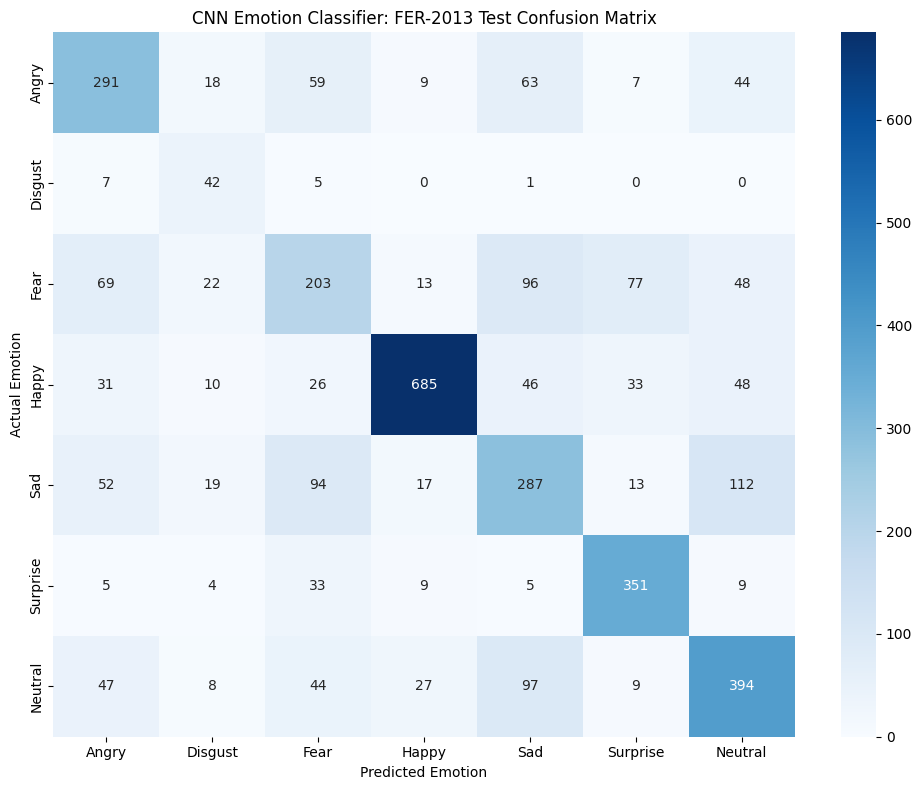


Saved to Google Drive:
/content/drive/MyDrive/emotion-detection-yolo/outputs/metrics/cnn_test_classification_report.csv
/content/drive/MyDrive/emotion-detection-yolo/outputs/metrics/cnn_test_confusion_matrix.png
/content/drive/MyDrive/emotion-detection-yolo/outputs/metrics/cnn_test_metrics_summary.json


In [ ]:
import os
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

METRICS_DIR = f"{PROJECT_ROOT}/outputs/metrics"
os.makedirs(METRICS_DIR, exist_ok=True)

# Use the trained model loaded in Cell 62
emotion_model.eval()

all_true_labels = []
all_predicted_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = emotion_model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_true_labels.extend(labels.cpu().numpy())
        all_predicted_labels.extend(predictions.cpu().numpy())

# Class names in the exact FER-2013 numeric order
class_names = [emotion_names[i] for i in range(7)]

# Overall metrics
test_accuracy = accuracy_score(all_true_labels, all_predicted_labels)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    all_true_labels,
    all_predicted_labels,
    average="macro",
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    all_true_labels,
    all_predicted_labels,
    average="weighted",
    zero_division=0
)

print("CNN TEST-SET RESULTS")
print("=" * 50)
print(f"Accuracy:           {test_accuracy * 100:.2f}%")
print(f"Macro Precision:    {macro_precision * 100:.2f}%")
print(f"Macro Recall:       {macro_recall * 100:.2f}%")
print(f"Macro F1-score:     {macro_f1 * 100:.2f}%")
print(f"Weighted F1-score:  {weighted_f1 * 100:.2f}%")

# Per-emotion precision, recall, and F1-score
report_dict = classification_report(
    all_true_labels,
    all_predicted_labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_csv_path = f"{METRICS_DIR}/cnn_test_classification_report.csv"
report_df.to_csv(report_csv_path)

print("\nPer-emotion classification report:")
display(report_df.round(3))

# Confusion matrix
cm = confusion_matrix(all_true_labels, all_predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("CNN Emotion Classifier: FER-2013 Test Confusion Matrix")
plt.tight_layout()

confusion_matrix_path = f"{METRICS_DIR}/cnn_test_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=200, bbox_inches="tight")
plt.show()

# Save a compact metrics summary
summary = {
    "test_accuracy_percent": round(test_accuracy * 100, 2),
    "macro_precision_percent": round(macro_precision * 100, 2),
    "macro_recall_percent": round(macro_recall * 100, 2),
    "macro_f1_percent": round(macro_f1 * 100, 2),
    "weighted_precision_percent": round(weighted_precision * 100, 2),
    "weighted_recall_percent": round(weighted_recall * 100, 2),
    "weighted_f1_percent": round(weighted_f1 * 100, 2)
}

summary_path = f"{METRICS_DIR}/cnn_test_metrics_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print("\nSaved to Google Drive:")
print(report_csv_path)
print(confusion_matrix_path)
print(summary_path)

## 6.2 YOLO Face Detector Evaluation Results

The YOLO detector is evaluated on the held-out WIDER FACE validation split.

The fine-tuned YOLOv8n face detector was evaluated on the held-out WIDER FACE validation set containing 2,576 images and 32,879 face instances.

| Metric | Result |
|---|---:|
| Precision | 83.50% |
| Recall | 54.92% |
| F1-score | 66.26% |
| mAP@50 | 61.11% |
| mAP@50–95 | 31.51% |

### Interpretation

The detector achieved high precision (83.50%), meaning that most predicted face bounding boxes correspond to real faces. This is important for the complete emotion-detection pipeline because the CNN emotion classifier should receive reliable face crops.

Recall is lower (54.92%) because WIDER FACE is a challenging benchmark containing very small faces, heavy occlusion, side profiles, blur, and crowded scenes. The compact YOLOv8n model was deliberately selected to prioritize fast real-time inference rather than maximum detection accuracy.

The detector achieved an inference speed of approximately 4.0 ms per image on a Tesla T4 GPU during validation. Combined with the CNN classifier, the complete video pipeline achieved 39.83 FPS on a recorded 29.98 FPS video, meeting the real-time requirement.

In [ ]:
import os
import glob

# Find every possible extracted wider_face_local folder
possible_roots = glob.glob("/content/**/wider_face_local", recursive=True)

# Keep only the folder that really contains validation images
valid_roots = [
    folder for folder in possible_roots
    if os.path.exists(f"{folder}/images/val")
]

if len(valid_roots) == 0:
    raise FileNotFoundError(
        "Could not find the extracted WIDER FACE validation dataset."
    )

# Use the correct extracted folder
WIDER_LOCAL_ROOT = valid_roots[0]
WIDER_DATA_YAML = f"{WIDER_LOCAL_ROOT}/data.yaml"

yaml_content = f"""train: {WIDER_LOCAL_ROOT}/images/train
val: {WIDER_LOCAL_ROOT}/images/val

nc: 1
names: ['face']
"""

with open(WIDER_DATA_YAML, "w") as f:
    f.write(yaml_content)

val_images = len([
    file for file in os.listdir(f"{WIDER_LOCAL_ROOT}/images/val")
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Correct WIDER FACE folder found:")
print(WIDER_LOCAL_ROOT)
print(f"Validation images: {val_images}")
print(f"YOLO YAML created: {WIDER_DATA_YAML}")


Correct WIDER FACE folder found:
/content/content/wider_face_local
Validation images: 2576
YOLO YAML created: /content/content/wider_face_local/data.yaml


In [ ]:
# Evaluate trained YOLO face detector on WIDER FACE validation data

import os
import json

YOLO_METRICS_DIR = f"{PROJECT_ROOT}/outputs/metrics"
os.makedirs(YOLO_METRICS_DIR, exist_ok=True)

# Evaluate the existing trained YOLO face detector
yolo_metrics = face_model.val(
    data=WIDER_DATA_YAML,
    split="val",
    imgsz=640,
    batch=16,
    conf=0.001,
    plots=True,
    project=YOLO_METRICS_DIR,
    name="yolo_face_validation",
    exist_ok=True,
    verbose=True
)

# Read metrics returned by Ultralytics
yolo_precision = float(yolo_metrics.box.mp)
yolo_recall = float(yolo_metrics.box.mr)
yolo_map50 = float(yolo_metrics.box.map50)
yolo_map50_95 = float(yolo_metrics.box.map)

# Calculate F1-score from precision and recall
yolo_f1 = (
    2 * yolo_precision * yolo_recall / (yolo_precision + yolo_recall)
    if (yolo_precision + yolo_recall) > 0
    else 0.0
)

print("\nYOLO FACE DETECTOR VALIDATION RESULTS")
print("=" * 50)
print(f"Precision:   {yolo_precision * 100:.2f}%")
print(f"Recall:      {yolo_recall * 100:.2f}%")
print(f"F1-score:    {yolo_f1 * 100:.2f}%")
print(f"mAP@50:      {yolo_map50 * 100:.2f}%")
print(f"mAP@50-95:   {yolo_map50_95 * 100:.2f}%")

# Save concise results to Drive
yolo_summary = {
    "validation_images": 2576,
    "precision_percent": round(yolo_precision * 100, 2),
    "recall_percent": round(yolo_recall * 100, 2),
    "f1_score_percent": round(yolo_f1 * 100, 2),
    "map50_percent": round(yolo_map50 * 100, 2),
    "map50_95_percent": round(yolo_map50_95 * 100, 2)
}

yolo_summary_path = f"{YOLO_METRICS_DIR}/yolo_face_validation_metrics.json"

with open(yolo_summary_path, "w") as f:
    json.dump(yolo_summary, f, indent=4)

print(f"\nMetrics JSON saved to:\n{yolo_summary_path}")
print(f"YOLO validation plots saved to:\n{yolo_metrics.save_dir}")

Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1593.7±933.8 MB/s, size: 169.1 KB)
val: Scanning /content/content/wider_face_local/labels/val... 2576 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2576/2576 1.0Kit/s 2.5s
val: New cache created: /content/content/wider_face_local/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 161/161 4.7it/s 34.6s
                   all       2576      32879      0.835      0.549      0.611      0.315
Speed: 1.2ms preprocess, 4.0ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /content/drive/MyDrive/emotion-detection-yolo/outputs/metrics/yolo_face_validation

YOLO FACE DETECTOR VALIDATION RESULTS
Precision:   83.50%
Recall:      54.92%
F1-score:    66.26%
mAP@50:      61.11%
mAP@50-95:   31.51%

Metrics JSON saved to:
/content/drive/MyDrive/emotion-detection-yolo/out

# 7. Robustness Experiments

## Experiement 1 - Confidence-Aware Emotion Predictions

A raw CNN always returns the emotion class with the highest probability, even when its confidence is low. In real video, low-confidence predictions can occur because of blur, poor lighting, occlusion, side-profile faces, small face crops, or expressions that overlap visually.

To make the system more reliable, a confidence threshold is applied after CNN inference:

- If the highest CNN emotion probability is **45% or greater**, the predicted emotion is displayed.
- If the highest probability is **below 45%**, the system displays **Uncertain**.

This does not change or retrain the YOLO detector or CNN classifier. It is an inference-time reliability layer that prevents the interface from presenting a low-confidence prediction as a definite emotional state.

The threshold can be adjusted later depending on the required balance between showing more predictions and being more cautious.

In [10]:
EMOTION_CONFIDENCE_THRESHOLD = 45.0

def predict_emotion(face_bgr):
    gray_face = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
    gray_face = cv2.resize(gray_face, (48, 48))

    face_pil = Image.fromarray(gray_face)
    face_tensor = val_transform(face_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = emotion_model(face_tensor)
        probabilities = torch.softmax(logits, dim=1)[0]

        emotion_id = int(torch.argmax(probabilities).item())
        confidence = float(probabilities[emotion_id].item() * 100)

    if confidence < EMOTION_CONFIDENCE_THRESHOLD:
        return "Uncertain", confidence

    return emotion_names[emotion_id], confidence

print("Confidence-aware emotion prediction enabled.")
print(f"Predictions below {EMOTION_CONFIDENCE_THRESHOLD:.0f}% show as Uncertain.")

Confidence-aware emotion prediction enabled.
Predictions below 45% show as Uncertain.


In [11]:
UNCERTAIN_OUTPUT_DIR = f"{PROJECT_ROOT}/outputs/videos/batch_results_with_uncertain"

os.makedirs(UNCERTAIN_OUTPUT_DIR, exist_ok=True)

print("New confidence-aware output videos will be saved here:")
print(UNCERTAIN_OUTPUT_DIR)

New confidence-aware output videos will be saved here:
/content/drive/MyDrive/emotion-detection-yolo/outputs/videos/batch_results_with_uncertain


**Batch process videos with confidence-aware Uncertain labels**

In [12]:
import glob
import time
import shutil
import cv2

LOCAL_UNCERTAIN_OUTPUT_DIR = "/content/emotion_uncertain_results"
os.makedirs(LOCAL_UNCERTAIN_OUTPUT_DIR, exist_ok=True)

input_videos = (
    glob.glob(f"{INPUT_VIDEO_DIR}/*.mp4") +
    glob.glob(f"{INPUT_VIDEO_DIR}/*.avi") +
    glob.glob(f"{INPUT_VIDEO_DIR}/*.mov")
)

if len(input_videos) == 0:
    raise FileNotFoundError(f"No videos found in: {INPUT_VIDEO_DIR}")

print(f"Found {len(input_videos)} input video(s).")
print(f"Confidence threshold: {EMOTION_CONFIDENCE_THRESHOLD:.0f}%")

for input_path in input_videos:
    video_name = os.path.splitext(os.path.basename(input_path))[0]

    local_output_path = (
        f"{LOCAL_UNCERTAIN_OUTPUT_DIR}/"
        f"uncertain_{video_name}.mp4"
    )

    drive_output_path = (
        f"{UNCERTAIN_OUTPUT_DIR}/"
        f"uncertain_{video_name}.mp4"
    )

    cap = cv2.VideoCapture(input_path)

    if not cap.isOpened():
        print(f"Skipping unreadable file: {input_path}")
        continue

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps <= 0:
        fps = 30.0

    writer = cv2.VideoWriter(
        local_output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height)
    )

    print(f"\nProcessing: {os.path.basename(input_path)}")
    frame_number = 0
    start_time = time.time()

    while True:
        success, frame = cap.read()

        if not success:
            break

        # Uses the updated predict_emotion() with Uncertain handling
        processed_frame, _ = process_frame(frame, face_confidence=0.40)
        writer.write(processed_frame)

        frame_number += 1

        if frame_number % 100 == 0:
            print(f"  Processed {frame_number}/{total_frames} frames")

    cap.release()
    writer.release()

    elapsed_time = time.time() - start_time
    pipeline_fps = frame_number / elapsed_time

    # Copy finalised local video to Google Drive
    shutil.copy2(local_output_path, drive_output_path)

    print(f"Completed: {frame_number} frames")
    print(f"CPU pipeline speed: {pipeline_fps:.2f} FPS")
    print(f"Saved: {drive_output_path}")

print("\nAll confidence-aware videos were completed.")

Found 3 input video(s).
Confidence threshold: 45%

Processing: multiple faces.mp4
  Processed 100/1298 frames
  Processed 200/1298 frames
  Processed 300/1298 frames
  Processed 400/1298 frames
  Processed 500/1298 frames
  Processed 600/1298 frames
  Processed 700/1298 frames
  Processed 800/1298 frames
  Processed 900/1298 frames
  Processed 1000/1298 frames
  Processed 1100/1298 frames
  Processed 1200/1298 frames
Completed: 1298 frames
CPU pipeline speed: 5.99 FPS
Saved: /content/drive/MyDrive/emotion-detection-yolo/outputs/videos/batch_results_with_uncertain/uncertain_multiple faces.mp4

Processing: dim lighting.mp4
  Processed 100/230 frames
  Processed 200/230 frames
Completed: 230 frames
CPU pipeline speed: 6.60 FPS
Saved: /content/drive/MyDrive/emotion-detection-yolo/outputs/videos/batch_results_with_uncertain/uncertain_dim lighting.mp4

Processing: single face.mp4
  Processed 100/361 frames
  Processed 200/361 frames
  Processed 300/361 frames
Completed: 361 frames
CPU pipeli

## 7.2 Experiment 2 - Temporal Smoothing

Per-face probability smoothing reduces frame-to-frame label flicker while retaining the uncertainty rule.

Frame-by-frame emotion classification can produce unstable labels. For example, the same face may be predicted as Happy in one frame, Neutral in the next frame, and Happy again immediately afterward. This behaviour is called prediction flickering.

To improve real-time usability, temporal smoothing is applied after CNN inference.

### Method

1. YOLO detects face bounding boxes in each frame.
2. Bounding-box overlap, measured using Intersection over Union (IoU), is used to associate the same face across nearby frames.
3. For each tracked face, the CNN probability vectors from the latest five frames are stored.
4. The five probability vectors are averaged.
5. The emotion with the highest averaged probability is displayed.
6. If the smoothed confidence is below 45%, the system displays `Uncertain`.

### Benefits

- Reduces unstable emotion-label flickering.
- Produces more readable output videos.
- Handles multiple faces separately by maintaining a separate short history for each face.
- Does not require retraining YOLO or the CNN.

### Trade-off

Smoothing slightly delays sudden label changes because the result considers the recent frame history. A five-frame window was selected to balance stable output with responsive real-time behaviour.

In [13]:
SMOOTHED_OUTPUT_DIR = f"{PROJECT_ROOT}/outputs/videos/batch_results_smoothed"

os.makedirs(SMOOTHED_OUTPUT_DIR, exist_ok=True)

print("Temporal-smoothed videos will be saved here:")
print(SMOOTHED_OUTPUT_DIR)

Temporal-smoothed videos will be saved here:
/content/drive/MyDrive/emotion-detection-yolo/outputs/videos/batch_results_smoothed


In [14]:
from collections import deque

SMOOTHING_WINDOW = 5          # Number of recent frames used per face
TRACK_IOU_THRESHOLD = 0.30    # Face boxes must overlap this much to be same person
TRACK_MAX_MISSING_FRAMES = 15 # Keep a missing face track briefly

face_tracks = {}
next_track_id = 1
video_frame_index = 0


def calculate_iou(box_a, box_b):
    """Calculate intersection-over-union between two bounding boxes."""

    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_width = max(0, inter_x2 - inter_x1)
    inter_height = max(0, inter_y2 - inter_y1)

    intersection = inter_width * inter_height

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    union = area_a + area_b - intersection

    return intersection / union if union > 0 else 0.0


def predict_emotion_probabilities(face_bgr):
    """
    Return the full seven-emotion probability vector from the CNN.
    Temporal smoothing averages these probabilities over nearby frames.
    """

    gray_face = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
    gray_face = cv2.resize(gray_face, (48, 48))

    face_pil = Image.fromarray(gray_face)
    face_tensor = val_transform(face_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = emotion_model(face_tensor)
        probabilities = torch.softmax(logits, dim=1)[0]

    return probabilities.cpu().numpy()


def get_track_id(current_box, used_track_ids):
    """
    Match the current face to its previous bounding box.
    A new track is created if no matching face exists.
    """

    global next_track_id

    best_track_id = None
    best_iou = 0.0

    for track_id, track_data in face_tracks.items():
        if track_id in used_track_ids:
            continue

        overlap = calculate_iou(current_box, track_data["last_box"])

        if overlap > best_iou:
            best_iou = overlap
            best_track_id = track_id

    if best_track_id is not None and best_iou >= TRACK_IOU_THRESHOLD:
        return best_track_id

    track_id = next_track_id
    next_track_id += 1

    face_tracks[track_id] = {
        "last_box": current_box,
        "probability_history": deque(maxlen=SMOOTHING_WINDOW),
        "last_seen_frame": video_frame_index
    }

    return track_id


def process_frame(frame, face_confidence=0.40):
    """
    YOLO detects faces. CNN predicts emotion. Each face prediction is
    smoothed across recent frames belonging to the same tracked face.
    """

    global video_frame_index

    output_frame = frame.copy()
    yolo_results = face_model.predict(
        source=frame,
        conf=face_confidence,
        imgsz=640,
        verbose=False
    )

    result = yolo_results[0]
    face_count = 0
    used_track_ids = set()

    if result.boxes is not None and len(result.boxes) > 0:

        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(frame.shape[1], x2)
            y2 = min(frame.shape[0], y2)

            current_box = [x1, y1, x2, y2]
            face_crop = frame[y1:y2, x1:x2]

            if face_crop.size == 0 or face_crop.shape[0] < 20 or face_crop.shape[1] < 20:
                continue

            # Get current CNN probabilities
            current_probabilities = predict_emotion_probabilities(face_crop)

            # Match this face to a track and update its probability history
            track_id = get_track_id(current_box, used_track_ids)
            used_track_ids.add(track_id)

            face_tracks[track_id]["last_box"] = current_box
            face_tracks[track_id]["last_seen_frame"] = video_frame_index
            face_tracks[track_id]["probability_history"].append(
                current_probabilities
            )

            # Average probabilities across the last few frames for this face
            smoothed_probabilities = np.mean(
                np.stack(face_tracks[track_id]["probability_history"]),
                axis=0
            )

            emotion_id = int(np.argmax(smoothed_probabilities))
            emotion_confidence = float(
                smoothed_probabilities[emotion_id] * 100
            )

            if emotion_confidence < EMOTION_CONFIDENCE_THRESHOLD:
                displayed_emotion = "Uncertain"
                colour = (0, 165, 255)  # Orange
            else:
                displayed_emotion = emotion_names[emotion_id]
                colour = (0, 255, 0)    # Green

            cv2.rectangle(
                output_frame,
                (x1, y1),
                (x2, y2),
                colour,
                2
            )

            label = f"{displayed_emotion} ({emotion_confidence:.1f}%)"

            cv2.putText(
                output_frame,
                label,
                (x1, max(y1 - 10, 25)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                colour,
                2,
                cv2.LINE_AA
            )

            face_count += 1

    # Remove tracks for faces that have been absent for too long
    expired_track_ids = [
        track_id
        for track_id, track_data in face_tracks.items()
        if video_frame_index - track_data["last_seen_frame"] > TRACK_MAX_MISSING_FRAMES
    ]

    for track_id in expired_track_ids:
        del face_tracks[track_id]

    video_frame_index += 1

    return output_frame, face_count


print("Temporal smoothing is enabled.")
print(f"Each face uses the last {SMOOTHING_WINDOW} frames for a stable emotion label.")
print("Green = accepted prediction | Orange = Uncertain")

Temporal smoothing is enabled.
Each face uses the last 5 frames for a stable emotion label.
Green = accepted prediction | Orange = Uncertain


In [15]:
import glob
import time
import shutil
import cv2

LOCAL_SMOOTHED_OUTPUT_DIR = "/content/emotion_smoothed_results"
os.makedirs(LOCAL_SMOOTHED_OUTPUT_DIR, exist_ok=True)

input_videos = (
    glob.glob(f"{INPUT_VIDEO_DIR}/*.mp4") +
    glob.glob(f"{INPUT_VIDEO_DIR}/*.avi") +
    glob.glob(f"{INPUT_VIDEO_DIR}/*.mov")
)

if len(input_videos) == 0:
    raise FileNotFoundError(f"No videos found in: {INPUT_VIDEO_DIR}")

print(f"Found {len(input_videos)} input video(s).")
print(f"Smoothing window: {SMOOTHING_WINDOW} frames")
print(f"Confidence threshold: {EMOTION_CONFIDENCE_THRESHOLD:.0f}%")

for input_path in input_videos:
    video_name = os.path.splitext(os.path.basename(input_path))[0]

    # Reset tracking history before starting a different video
    face_tracks.clear()
    next_track_id = 1
    video_frame_index = 0

    local_output_path = (
        f"{LOCAL_SMOOTHED_OUTPUT_DIR}/"
        f"smoothed_{video_name}.mp4"
    )

    drive_output_path = (
        f"{SMOOTHED_OUTPUT_DIR}/"
        f"smoothed_{video_name}.mp4"
    )

    cap = cv2.VideoCapture(input_path)

    if not cap.isOpened():
        print(f"Skipping unreadable file: {input_path}")
        continue

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps <= 0:
        fps = 30.0

    writer = cv2.VideoWriter(
        local_output_path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height)
    )

    print(f"\nProcessing: {os.path.basename(input_path)}")
    frame_number = 0
    start_time = time.time()

    while True:
        success, frame = cap.read()

        if not success:
            break

        # Uses the temporal-smoothed process_frame() function
        processed_frame, _ = process_frame(frame, face_confidence=0.40)
        writer.write(processed_frame)

        frame_number += 1

        if frame_number % 100 == 0:
            print(f"  Processed {frame_number}/{total_frames} frames")

    cap.release()
    writer.release()

    elapsed_time = time.time() - start_time
    pipeline_fps = frame_number / elapsed_time

    # Copy the finalised output to Google Drive
    shutil.copy2(local_output_path, drive_output_path)

    print(f"Completed: {frame_number} frames")
    print(f"CPU pipeline speed: {pipeline_fps:.2f} FPS")
    print(f"Saved: {drive_output_path}")

print("\nAll temporal-smoothed videos were completed.")

Found 3 input video(s).
Smoothing window: 5 frames
Confidence threshold: 45%

Processing: multiple faces.mp4
  Processed 100/1298 frames
  Processed 200/1298 frames
  Processed 300/1298 frames
  Processed 400/1298 frames
  Processed 500/1298 frames
  Processed 600/1298 frames
  Processed 700/1298 frames
  Processed 800/1298 frames
  Processed 900/1298 frames
  Processed 1000/1298 frames
  Processed 1100/1298 frames
  Processed 1200/1298 frames
Completed: 1298 frames
CPU pipeline speed: 5.63 FPS
Saved: /content/drive/MyDrive/emotion-detection-yolo/outputs/videos/batch_results_smoothed/smoothed_multiple faces.mp4

Processing: dim lighting.mp4
  Processed 100/230 frames
  Processed 200/230 frames
Completed: 230 frames
CPU pipeline speed: 6.46 FPS
Saved: /content/drive/MyDrive/emotion-detection-yolo/outputs/videos/batch_results_smoothed/smoothed_dim lighting.mp4

Processing: single face.mp4
  Processed 100/361 frames
  Processed 200/361 frames
  Processed 300/361 frames
Completed: 361 fram

# 8. Frame-Level Video Analytics

In addition to producing an annotated output video, the system generates a structured CSV report for every processed input video.

Each report records the prediction data generated by the YOLO + CNN pipeline for every frame:

- Video filename
- Frame number
- Timestamp in seconds
- Number of faces detected in the frame
- Face bounding-box coordinates
- YOLO face-detection confidence
- CNN predicted emotion
- CNN emotion-classification confidence

### Why This Feature Is Included

The assignment requires the pipeline to return facial emotions with bounding boxes for each processed frame. The annotated video provides a visual result, while the CSV report provides the same information in a machine-readable format.

This makes the system more useful for downstream analysis, auditing, dashboards, or API consumers. For example, a user can identify the timestamp of an emotion prediction, inspect its confidence, or analyze how many faces were detected throughout a video.

The report is generated without retraining either model. It records predictions already produced during inference.

In [ ]:
# Check whether frame-level video reports are already saved in Drive

import os
import glob

REPORT_DIR = f"{PROJECT_ROOT}/outputs/reports"

report_files = glob.glob(f"{REPORT_DIR}/*.csv")

print("Reports folder:", REPORT_DIR)
print("CSV reports found:")

for file_path in report_files:
    print("-", os.path.basename(file_path))

if len(report_files) == 0:
    print("\nNo CSV reports found yet. We will create them later when GPU is available.")

Reports folder: /content/drive/MyDrive/emotion-detection-yolo/outputs/reports
CSV reports found:
- multiple faces_emotion_report.csv
- single face_emotion_report.csv
- dim lighting_emotion_report.csv
- batch_analysis_summary.csv


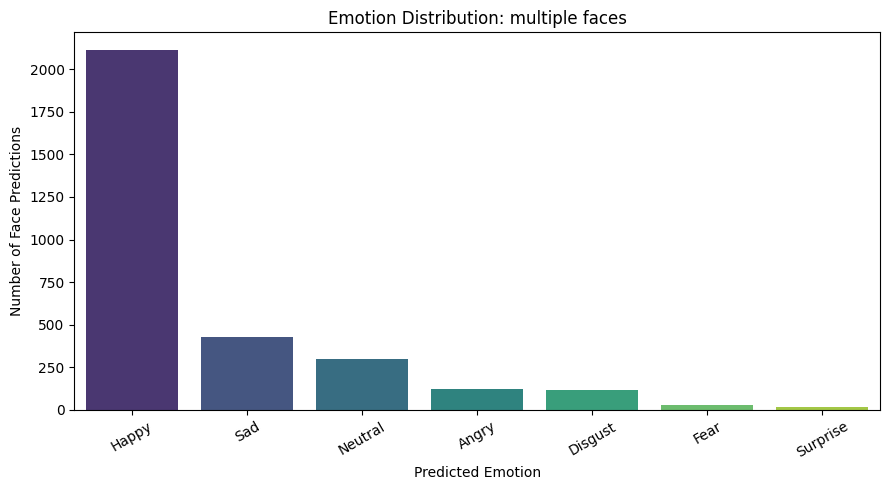

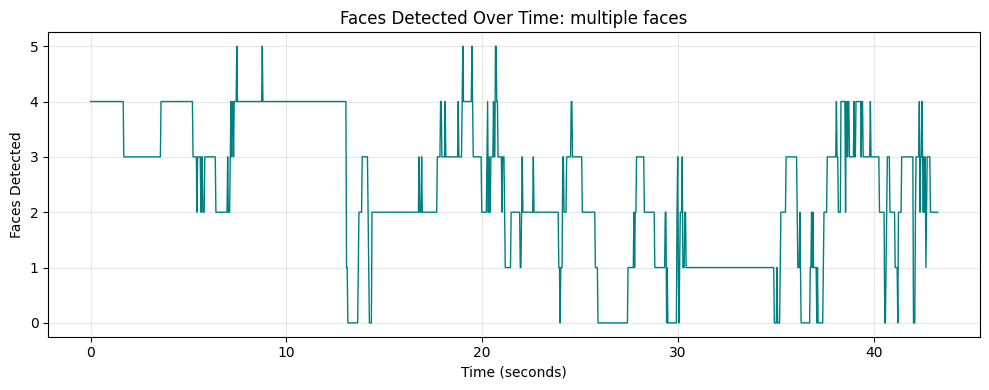

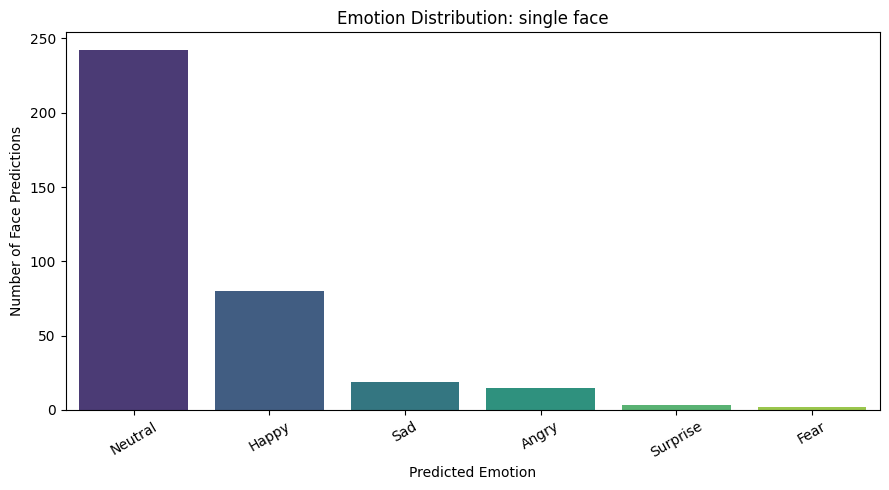

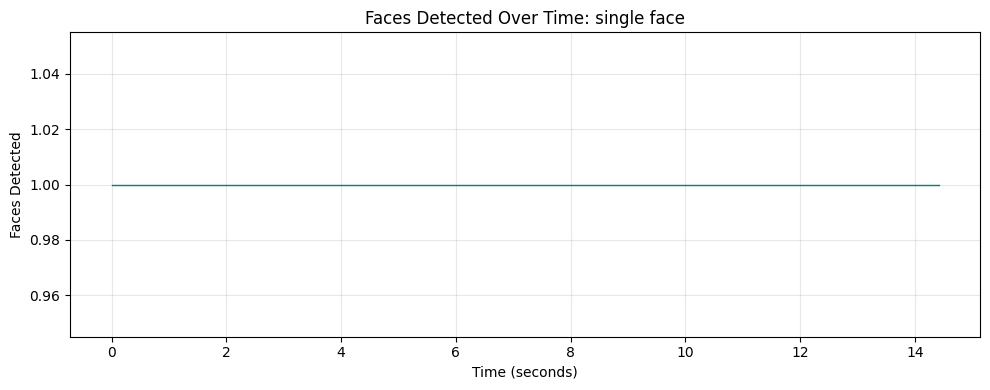

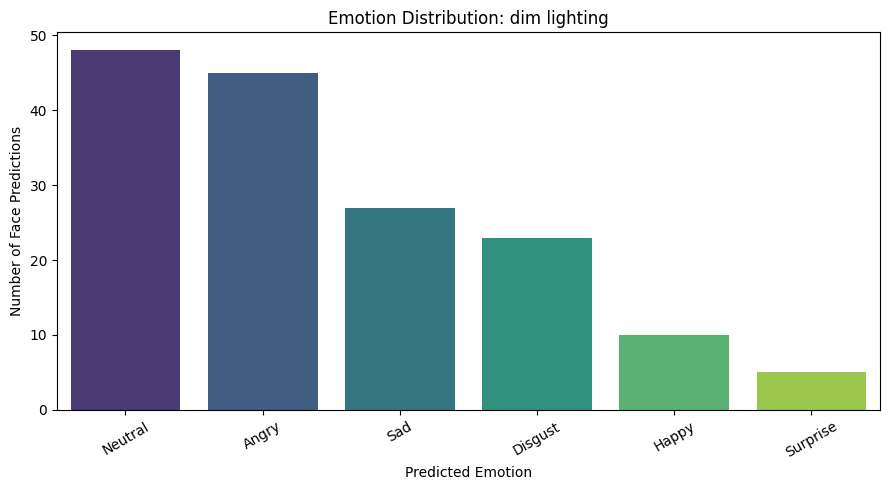

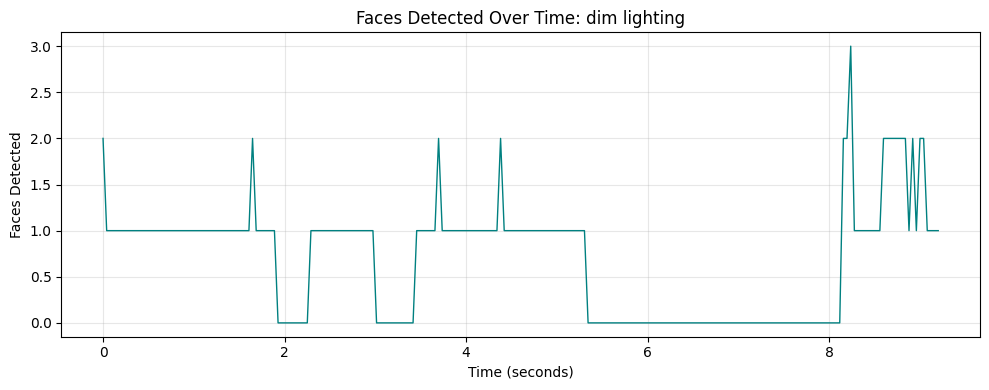

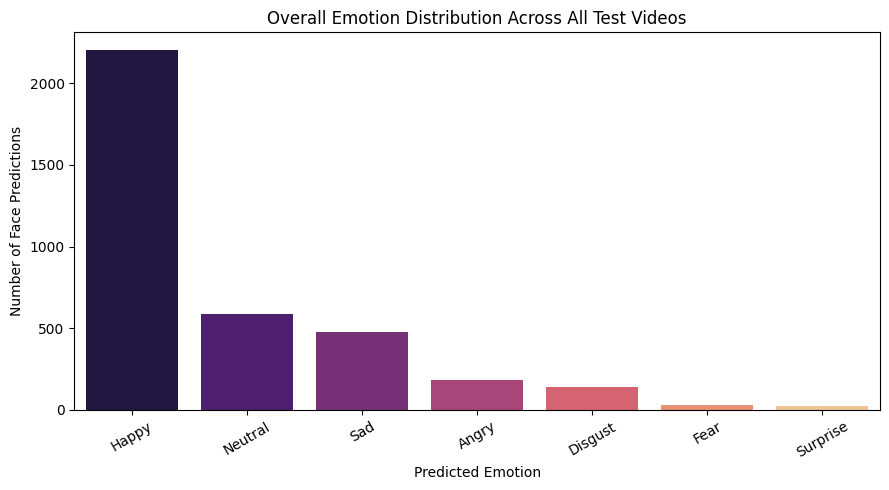

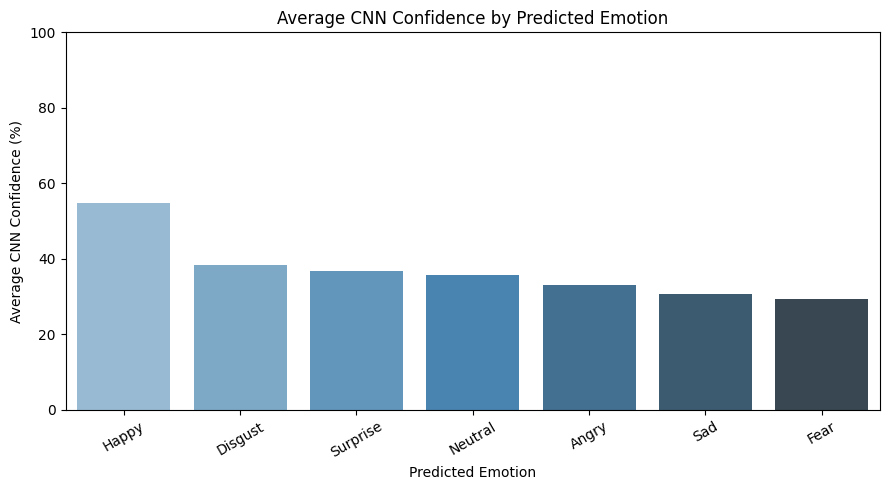


Charts saved in:
/content/drive/MyDrive/emotion-detection-yolo/outputs/reports/visualizations

Analytics summary saved as:
/content/drive/MyDrive/emotion-detection-yolo/outputs/reports/video_analytics_summary.csv


,video_name,total_frames_with_emotion_predictions,most_frequent_emotion,most_frequent_emotion_count,average_cnn_confidence_percent,maximum_faces_in_one_frame
0,multiple faces,3120,Happy,2111,48.04,5
1,single face,361,Neutral,242,38.28,1
2,dim lighting,158,Neutral,48,35.48,3


In [ ]:
# Creatimg visual charts from the saved frame-level CSV reports

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

VISUALIZATION_DIR = f"{REPORT_DIR}/visualizations"
os.makedirs(VISUALIZATION_DIR, exist_ok=True)

# Use only detailed per-video reports, not the batch summary CSV
detailed_report_paths = [
    path for path in glob.glob(f"{REPORT_DIR}/*_emotion_report.csv")
]

all_detected_faces = []
video_summary_rows = []

for report_path in detailed_report_paths:
    df = pd.read_csv(report_path)
    video_name = os.path.basename(report_path).replace("_emotion_report.csv", "")

    # Keep only rows where a valid face/emotion was detected
    detected_df = df[df["predicted_emotion"] != "No face detected"].copy()

    if len(detected_df) == 0:
        print(f"No detected faces in: {video_name}")
        continue

    # Ensure confidence is numeric
    detected_df["cnn_emotion_confidence"] = pd.to_numeric(
        detected_df["cnn_emotion_confidence"],
        errors="coerce"
    )

    # ---------- Chart 1: Emotion distribution for this video ----------
    emotion_counts = detected_df["predicted_emotion"].value_counts()

    plt.figure(figsize=(9, 5))
    sns.barplot(
        x=emotion_counts.index,
        y=emotion_counts.values,
        hue=emotion_counts.index,
        palette="viridis",
        legend=False
    )
    plt.title(f"Emotion Distribution: {video_name}")
    plt.xlabel("Predicted Emotion")
    plt.ylabel("Number of Face Predictions")
    plt.xticks(rotation=30)
    plt.tight_layout()

    safe_name = video_name.replace(" ", "_")
    chart_path = f"{VISUALIZATION_DIR}/{safe_name}_emotion_distribution.png"
    plt.savefig(chart_path, dpi=200)
    plt.show()

    # ---------- Chart 2: Faces detected over time ----------
    faces_by_frame = (
        df.groupby(["frame_number", "timestamp_seconds"])["faces_detected_in_frame"]
        .max()
        .reset_index()
    )

    plt.figure(figsize=(10, 4))
    plt.plot(
        faces_by_frame["timestamp_seconds"],
        faces_by_frame["faces_detected_in_frame"],
        color="teal",
        linewidth=1
    )
    plt.title(f"Faces Detected Over Time: {video_name}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Faces Detected")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    timeline_path = f"{VISUALIZATION_DIR}/{safe_name}_face_timeline.png"
    plt.savefig(timeline_path, dpi=200)
    plt.show()

    # Summary row for this video
    video_summary_rows.append({
        "video_name": video_name,
        "total_frames_with_emotion_predictions": len(detected_df),
        "most_frequent_emotion": emotion_counts.index[0],
        "most_frequent_emotion_count": int(emotion_counts.iloc[0]),
        "average_cnn_confidence_percent": round(
            detected_df["cnn_emotion_confidence"].mean(), 2
        ),
        "maximum_faces_in_one_frame": int(
            faces_by_frame["faces_detected_in_frame"].max()
        )
    })

    all_detected_faces.append(detected_df)

# ---------- Combined charts across all videos ----------
combined_df = pd.concat(all_detected_faces, ignore_index=True)

overall_emotions = combined_df["predicted_emotion"].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(
    x=overall_emotions.index,
    y=overall_emotions.values,
    hue=overall_emotions.index,
    palette="magma",
    legend=False
)
plt.title("Overall Emotion Distribution Across All Test Videos")
plt.xlabel("Predicted Emotion")
plt.ylabel("Number of Face Predictions")
plt.xticks(rotation=30)
plt.tight_layout()

overall_chart_path = f"{VISUALIZATION_DIR}/overall_emotion_distribution.png"
plt.savefig(overall_chart_path, dpi=200)
plt.show()

# Average confidence by emotion
confidence_by_emotion = (
    combined_df.groupby("predicted_emotion")["cnn_emotion_confidence"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(
    x=confidence_by_emotion.index,
    y=confidence_by_emotion.values,
    hue=confidence_by_emotion.index,
    palette="Blues_d",
    legend=False
)
plt.title("Average CNN Confidence by Predicted Emotion")
plt.xlabel("Predicted Emotion")
plt.ylabel("Average CNN Confidence (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30)
plt.tight_layout()

confidence_chart_path = f"{VISUALIZATION_DIR}/average_confidence_by_emotion.png"
plt.savefig(confidence_chart_path, dpi=200)
plt.show()

# Save one easy-to-read analytics summary
analytics_summary = pd.DataFrame(video_summary_rows)
analytics_summary_path = f"{REPORT_DIR}/video_analytics_summary.csv"
analytics_summary.to_csv(analytics_summary_path, index=False)

print("\nCharts saved in:")
print(VISUALIZATION_DIR)

print("\nAnalytics summary saved as:")
print(analytics_summary_path)

display(analytics_summary)

# 9. REST API

FastAPI packages the trained pipeline as a reusable video-processing service.

The trained models were packaged as a REST API using FastAPI. The API makes the emotion-detection pipeline usable outside the notebook.

### Why an API Is Needed

The notebook is suitable for model development, training, evaluation, and experimentation. However, an end user or another application should not need to open and run notebook cells to process a video.

The REST API exposes the trained YOLO + CNN pipeline as a reusable service.

### API Workflow

```text
Client or Web Interface
        ↓ uploads a video file
FastAPI Endpoint: POST /process-video
        ↓
YOLOv8 Face Detection
        ↓
CNN Emotion Classification
        ↓
Annotated Output Video + Frame-Level CSV Report
        ↓
API Response Returned to Client

In [7]:
# Create folders for the FastAPI deployment project

import os

API_ROOT = f"{PROJECT_ROOT}/api"

folders = [
    API_ROOT,
    f"{API_ROOT}/uploads",
    f"{API_ROOT}/outputs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("FastAPI project folders are ready:")
for folder in folders:
    print(folder)

FastAPI project folders are ready:
/content/drive/MyDrive/emotion-detection-yolo/api
/content/drive/MyDrive/emotion-detection-yolo/api/uploads
/content/drive/MyDrive/emotion-detection-yolo/api/outputs


**Creating inference.py — loads models and processes frames.**

In [ ]:
%%writefile /content/drive/MyDrive/emotion-detection-yolo/api/inference.py

import cv2
import numpy as np
import torch
import torch.nn as nn

from PIL import Image
from torchvision import transforms
from ultralytics import YOLO


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        batch_size, channels, _, _ = x.size()
        y = self.avg_pool(x).view(batch_size, channels)
        y = self.fc(y).view(batch_size, channels, 1, 1)
        return x * y.expand_as(x)


class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.se2 = SEBlock(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.se4 = SEBlock(256)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.4)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(256, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.se2(x)

        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.se4(x)

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))

        return self.fc2(x)


class EmotionVideoProcessor:
    """
    Loads the trained YOLO face detector and CNN emotion classifier.
    Provides functions to process individual video frames.
    """

    def __init__(
        self,
        yolo_weights_path,
        cnn_weights_path,
        face_confidence=0.40,
        emotion_confidence_threshold=45.0
    ):
        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.face_confidence = face_confidence
        self.emotion_confidence_threshold = emotion_confidence_threshold

        self.emotion_names = {
            0: "Angry",
            1: "Disgust",
            2: "Fear",
            3: "Happy",
            4: "Sad",
            5: "Surprise",
            6: "Neutral"
        }

        # Load trained YOLO face detector
        self.face_model = YOLO(yolo_weights_path)

        # Load trained CNN emotion classifier
        self.emotion_model = EmotionCNN(num_classes=7).to(self.device)

        checkpoint = torch.load(
            cnn_weights_path,
            map_location=self.device
        )

        self.emotion_model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        self.emotion_model.eval()

        # Same preprocessing used during CNN testing
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

    def predict_emotion(self, face_bgr):
        """Predict emotion and confidence from one detected face crop."""

        gray_face = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
        gray_face = cv2.resize(gray_face, (48, 48))

        face_pil = Image.fromarray(gray_face)
        face_tensor = self.transform(face_pil).unsqueeze(0).to(self.device)

        with torch.no_grad():
            logits = self.emotion_model(face_tensor)
            probabilities = torch.softmax(logits, dim=1)[0]

            emotion_id = int(torch.argmax(probabilities).item())
            confidence = float(probabilities[emotion_id].item() * 100)

        raw_emotion = self.emotion_names[emotion_id]

        if confidence < self.emotion_confidence_threshold:
            return "Uncertain", confidence, raw_emotion

        return raw_emotion, confidence, raw_emotion

    def process_frame(self, frame):
        """
        Detect faces with YOLO, classify every detected face with the CNN,
        draw annotations, and return frame-level prediction details.
        """

        output_frame = frame.copy()
        detections = []

        yolo_results = self.face_model.predict(
            source=frame,
            conf=self.face_confidence,
            imgsz=640,
            verbose=False
        )

        result = yolo_results[0]

        if result.boxes is None or len(result.boxes) == 0:
            return output_frame, detections

        for face_id, box in enumerate(result.boxes, start=1):
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            yolo_confidence = float(box.conf[0].cpu().numpy() * 100)

            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(frame.shape[1], x2)
            y2 = min(frame.shape[0], y2)

            face_crop = frame[y1:y2, x1:x2]

            if face_crop.size == 0 or face_crop.shape[0] < 20 or face_crop.shape[1] < 20:
                continue

            display_emotion, emotion_confidence, raw_emotion = self.predict_emotion(
                face_crop
            )

            # Orange means uncertain; green means accepted prediction
            colour = (0, 165, 255) if display_emotion == "Uncertain" else (0, 255, 0)

            cv2.rectangle(output_frame, (x1, y1), (x2, y2), colour, 2)

            label = f"{display_emotion} ({emotion_confidence:.1f}%)"
            cv2.putText(
                output_frame,
                label,
                (x1, max(y1 - 10, 25)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                colour,
                2,
                cv2.LINE_AA
            )

            detections.append({
                "face_id": face_id,
                "bounding_box": [int(x1), int(y1), int(x2), int(y2)],
                "yolo_face_confidence_percent": round(yolo_confidence, 2),
                "displayed_emotion": display_emotion,
                "raw_emotion": raw_emotion,
                "cnn_emotion_confidence_percent": round(emotion_confidence, 2)
            })

        return output_frame, detections

Writing /content/drive/MyDrive/emotion-detection-yolo/api/inference.py


**Developing main.py — receives video uploads and returns output links.**

In [ ]:
%%writefile /content/drive/MyDrive/emotion-detection-yolo/api/main.py

import csv
import shutil
import time
import uuid
from contextlib import asynccontextmanager
from pathlib import Path

import cv2
from fastapi import FastAPI, File, HTTPException, UploadFile
from fastapi.responses import FileResponse

from inference import EmotionVideoProcessor


# Project paths
PROJECT_ROOT = Path(__file__).resolve().parent.parent
API_ROOT = PROJECT_ROOT / "api"
UPLOAD_DIR = API_ROOT / "uploads"
OUTPUT_DIR = API_ROOT / "outputs"

YOLO_WEIGHTS_PATH = (
    PROJECT_ROOT / "models" / "face_detector" /
    "yolov8n_face" / "weights" / "best.pt"
)

CNN_WEIGHTS_PATH = (
    PROJECT_ROOT / "models" / "emotion_classifier" /
    "best_emotion_model.pt"
)

for folder in [UPLOAD_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


@asynccontextmanager
async def lifespan(app: FastAPI):
    """
    Load the two trained models once when the API starts.
    They are then reused for every video request.
    """

    app.state.processor = EmotionVideoProcessor(
        yolo_weights_path=str(YOLO_WEIGHTS_PATH),
        cnn_weights_path=str(CNN_WEIGHTS_PATH),
        face_confidence=0.40,
        emotion_confidence_threshold=45.0
    )

    print("YOLO face detector and CNN emotion classifier loaded.")
    yield
    print("API stopped.")


app = FastAPI(
    title="Video Emotion Detection API",
    description=(
        "Upload a video. The API detects faces using YOLOv8 and "
        "classifies facial emotions using a trained CNN."
    ),
    version="1.0.0",
    lifespan=lifespan
)


@app.get("/")
def root():
    return {
        "message": "Video Emotion Detection API is running.",
        "documentation": "/docs",
        "health_check": "/health"
    }


@app.get("/health")
def health():
    processor = app.state.processor

    return {
        "status": "healthy",
        "device": str(processor.device),
        "face_detection_model": "YOLOv8n fine-tuned on WIDER FACE",
        "emotion_classification_model": "Custom CNN trained on FER-2013"
    }


@app.post("/process-video")
async def process_video(video: UploadFile = File(...)):
    """
    Upload a video, process every frame, and return URLs for:
    - annotated emotion-detection video
    - frame-level CSV analytics report
    """

    allowed_extensions = {".mp4", ".avi", ".mov"}
    suffix = Path(video.filename).suffix.lower()

    if suffix not in allowed_extensions:
        raise HTTPException(
            status_code=400,
            detail="Only .mp4, .avi, and .mov video files are supported."
        )

    # Each request has an isolated job folder
    job_id = str(uuid.uuid4())
    job_upload_dir = UPLOAD_DIR / job_id
    job_output_dir = OUTPUT_DIR / job_id

    job_upload_dir.mkdir(parents=True, exist_ok=True)
    job_output_dir.mkdir(parents=True, exist_ok=True)

    input_video_path = job_upload_dir / f"input{suffix}"
    output_video_path = job_output_dir / "emotion_detection_output.mp4"
    report_path = job_output_dir / "frame_level_emotion_report.csv"

    # Save uploaded video
    with open(input_video_path, "wb") as buffer:
        shutil.copyfileobj(video.file, buffer)

    cap = cv2.VideoCapture(str(input_video_path))

    if not cap.isOpened():
        raise HTTPException(
            status_code=400,
            detail="The uploaded file could not be opened as a video."
        )

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps <= 0:
        fps = 30.0

    writer = cv2.VideoWriter(
        str(output_video_path),
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (width, height)
    )

    processor = app.state.processor
    report_rows = []

    frame_number = 0
    start_time = time.time()

    while True:
        success, frame = cap.read()

        if not success:
            break

        processed_frame, detections = processor.process_frame(frame)
        writer.write(processed_frame)

        timestamp_seconds = round(frame_number / fps, 3)

        # Record all detected faces in the frame
        if detections:
            for detection in detections:
                report_rows.append({
                    "frame_number": frame_number,
                    "timestamp_seconds": timestamp_seconds,
                    "faces_detected_in_frame": len(detections),
                    **detection
                })
        else:
            report_rows.append({
                "frame_number": frame_number,
                "timestamp_seconds": timestamp_seconds,
                "faces_detected_in_frame": 0,
                "face_id": None,
                "bounding_box": None,
                "yolo_face_confidence_percent": None,
                "displayed_emotion": "No face detected",
                "raw_emotion": None,
                "cnn_emotion_confidence_percent": None
            })

        frame_number += 1

    cap.release()
    writer.release()

    processing_time_seconds = round(time.time() - start_time, 2)
    processing_fps = round(
        frame_number / processing_time_seconds,
        2
    ) if processing_time_seconds > 0 else 0.0

    # Save machine-readable frame-level report
    csv_columns = [
        "frame_number",
        "timestamp_seconds",
        "faces_detected_in_frame",
        "face_id",
        "bounding_box",
        "yolo_face_confidence_percent",
        "displayed_emotion",
        "raw_emotion",
        "cnn_emotion_confidence_percent"
    ]

    with open(report_path, "w", newline="", encoding="utf-8") as csv_file:
        writer_csv = csv.DictWriter(csv_file, fieldnames=csv_columns)
        writer_csv.writeheader()
        writer_csv.writerows(report_rows)

    return {
        "message": "Video processed successfully.",
        "job_id": job_id,
        "input_video": video.filename,
        "total_frames_processed": frame_number,
        "input_video_fps": round(fps, 2),
        "pipeline_fps": processing_fps,
        "processing_time_seconds": processing_time_seconds,
        "processed_video_url": f"/download/{job_id}/emotion_detection_output.mp4",
        "analytics_report_url": f"/download/{job_id}/frame_level_emotion_report.csv"
    }


@app.get("/download/{job_id}/{file_name}")
def download_output(job_id: str, file_name: str):
    """
    Download a processed video or its CSV report.
    """

    allowed_files = {
        "emotion_detection_output.mp4",
        "frame_level_emotion_report.csv"
    }

    if file_name not in allowed_files:
        raise HTTPException(status_code=404, detail="File not found.")

    output_path = OUTPUT_DIR / job_id / file_name

    if not output_path.exists():
        raise HTTPException(status_code=404, detail="Job output not found.")

    media_type = "video/mp4" if file_name.endswith(".mp4") else "text/csv"

    return FileResponse(
        path=str(output_path),
        media_type=media_type,
        filename=file_name
    )

Writing /content/drive/MyDrive/emotion-detection-yolo/api/main.py


Clear requirement.txt file for API

In [ ]:
%%writefile /content/drive/MyDrive/emotion-detection-yolo/api/requirements.txt

fastapi
uvicorn[standard]
python-multipart
ultralytics
opencv-python-headless
torch
torchvision
pandas
numpy
pillow

Writing /content/drive/MyDrive/emotion-detection-yolo/api/requirements.txt


In [ ]:
# Install and verify FastAPI project dependencies

!pip install -q -r "{API_ROOT}/requirements.txt"

from fastapi import FastAPI
import uvicorn
import multipart

print("FastAPI dependencies installed successfully.")
print("The API is ready for a health-check test.")

FastAPI dependencies installed successfully.
The API is ready for a health-check test.


### API Health-Check Verification

The FastAPI server was launched successfully and verified through the interactive `/docs` interface.

A request to `GET /health` returned HTTP status code `200` with the response:

```json
{
  "status": "healthy",
  "device": "cpu",
  "face_detection_model": "YOLOv8n fine-tuned on WIDER FACE",
  "emotion_classification_model": "Custom CNN trained on FER-2013"
}

In [ ]:
import os
import sys
import time
import subprocess
import requests

API_LOG_PATH = f"{API_ROOT}/api_server.log"

# Start FastAPI in the background.
# The server loads the saved YOLO and CNN models once at startup.
api_log = open(API_LOG_PATH, "w")

api_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "uvicorn",
        "main:app",
        "--host",
        "0.0.0.0",
        "--port",
        "8000"
    ],
    cwd=API_ROOT,
    stdout=api_log,
    stderr=subprocess.STDOUT
)

print("Starting FastAPI server and loading models...")

# Wait until the API responds, up to 60 seconds
api_ready = False

for _ in range(30):
    try:
        response = requests.get("http://127.0.0.1:8000/health", timeout=2)

        if response.status_code == 200:
            api_ready = True
            print("\nAPI health-check response:")
            print(response.json())
            break

    except requests.exceptions.ConnectionError:
        time.sleep(2)

if not api_ready:
    print("\nAPI did not start. Read the server log with:")
    print(f'!cat "{API_LOG_PATH}"')
else:
    from google.colab.output import eval_js

    api_url = eval_js("google.colab.kernel.proxyPort(8000)")

    print("\nFastAPI is running.")
    print("Open this API documentation page:")
    print(f"{api_url}/docs")

Starting FastAPI server and loading models...

API health-check response:
{'status': 'healthy', 'device': 'cpu', 'face_detection_model': 'YOLOv8n fine-tuned on WIDER FACE', 'emotion_classification_model': 'Custom CNN trained on FER-2013'}

FastAPI is running.
Open this API documentation page:
https://8000-m-s-kkb-use1b1-21gjcpiwr26zk-b.us-east1-1.prod.colab.dev/docs


## API Restart Note

The FastAPI server is temporary in Colab. After a runtime reconnect, run Runtime Setup, install the API requirements, and start the API server again. The saved API source files remain in Google Drive.


**To open api again in the same Colab session, rerun this cell**

In [ ]:
from google.colab.output import eval_js

api_url = eval_js("google.colab.kernel.proxyPort(8000)")
print(f"{api_url}/docs")

When Colab disconnects or restarts later, the server stops. To reopen the API then, you only need to:


1.   Run the notebook setup cell to mount Drive.
2.   Define API_ROOT again:
3.   Run the dependency-install cell.
4.   Run the FastAPI-server-start cell.





In [ ]:
API_ROOT = f"{PROJECT_ROOT}/api"

### Video-Processing API Test

The `POST /process-video` endpoint was tested through FastAPI's interactive `/docs` interface using a recorded single-face video.

The API successfully returned HTTP status code `200` and processed all 361 video frames.

| Result | Value |
|---|---:|
| Input video frame rate | 24.98 FPS |
| Frames processed | 361 |
| CPU processing speed | 5.03 FPS |
| Processing time | 71.72 seconds |

The API generated two downloadable outputs:

- `emotion_detection_output.mp4` — annotated video with face bounding boxes and emotion labels.
- `frame_level_emotion_report.csv` — machine-readable prediction details for every processed frame.

The API test was executed on CPU. GPU deployment is recommended for real-time API processing; the GPU notebook benchmark achieved 39.83 FPS.

# 10. Streamlit Web Interface

A lightweight web UI for uploading a video and viewing the annotated emotion-detection
output in the browser, without needing to use the FastAPI `/docs` page directly.

This lives in its own `web_app/` folder (separate from `api/`) and reuses the same
trained model-loading logic via a copy of `inference.py`, so the two interfaces
(REST API and web UI) stay independent of each other.

**Create the folder structure**

In [5]:
WEB_APP_ROOT = f"{PROJECT_ROOT}/web_app"
os.makedirs(WEB_APP_ROOT, exist_ok=True)
print(WEB_APP_ROOT)

/content/drive/MyDrive/emotion-detection-yolo/web_app


**Copying inference.py into the web app folder (keeps it self-contained)**

In [8]:
import shutil

shutil.copy(f"{API_ROOT}/inference.py", f"{WEB_APP_ROOT}/inference.py")
print("Copied inference.py into web_app/")

Copied inference.py into web_app/


### Reuse the inference logic in the web app

The Streamlit interface needs the same model-loading and frame-processing logic
as the FastAPI service. Rather than importing across folders, a copy of
`inference.py` is placed directly inside `web_app/`, so the two interfaces
(REST API and web UI) stay fully independent of each other.

### Build the Streamlit app file

In [9]:
%%writefile /content/drive/MyDrive/emotion-detection-yolo/web_app/streamlit_app.py

import streamlit as st
import tempfile
import os
import cv2
from pathlib import Path
from inference import EmotionVideoProcessor

st.set_page_config(page_title="Emotion Detection", layout="centered")
st.title("🎭 Video Emotion Detection")
st.write("Upload a short video. YOLOv8 detects faces, a custom CNN classifies each face's emotion.")

PROJECT_ROOT = Path(__file__).resolve().parent.parent
YOLO_WEIGHTS = str(PROJECT_ROOT / "models/face_detector/yolov8n_face/weights/best.pt")
CNN_WEIGHTS = str(PROJECT_ROOT / "models/emotion_classifier/best_emotion_model.pt")

@st.cache_resource
def load_processor():
    return EmotionVideoProcessor(
        yolo_weights_path=YOLO_WEIGHTS,
        cnn_weights_path=CNN_WEIGHTS,
        face_confidence=0.40,
        emotion_confidence_threshold=45.0
    )

processor = load_processor()
st.success(f"Models loaded. Running on: {processor.device}")

uploaded_file = st.file_uploader("Upload a video", type=["mp4", "avi", "mov"])

if uploaded_file is not None:
    with tempfile.NamedTemporaryFile(delete=False, suffix=".mp4") as tmp_in:
        tmp_in.write(uploaded_file.read())
        input_path = tmp_in.name

    st.video(input_path)

    if st.button("Run Emotion Detection"):
        with st.spinner("Processing video frame by frame..."):
            cap = cv2.VideoCapture(input_path)
            fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

            output_path = input_path.replace(".mp4", "_output.mp4")
            writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

            frame_count = 0
            while True:
                success, frame = cap.read()
                if not success:
                    break
                processed_frame, detections = processor.process_frame(frame)
                writer.write(processed_frame)
                frame_count += 1

            cap.release()
            writer.release()

        st.success(f"Done! Processed {frame_count} frames.")
        st.video(output_path)

        with open(output_path, "rb") as f:
            st.download_button("Download annotated video", f, file_name="emotion_output.mp4")

    os.unlink(input_path)

Writing /content/drive/MyDrive/emotion-detection-yolo/web_app/streamlit_app.py


### Web app dependencies

In [10]:
%%writefile /content/drive/MyDrive/emotion-detection-yolo/web_app/requirements.txt
streamlit
ultralytics
opencv-python-headless
torch
torchvision
pillow
numpy

Writing /content/drive/MyDrive/emotion-detection-yolo/web_app/requirements.txt


### !!!!!!!!This code failed run the second cell after this cell!!!!!

In [11]:
!pip install -q streamlit

import subprocess, sys, time
from google.colab.output import eval_js

streamlit_log = open(f"{WEB_APP_ROOT}/streamlit.log", "w")
streamlit_process = subprocess.Popen(
    [sys.executable, "-m", "streamlit", "run", "streamlit_app.py",
     "--server.port", "8501", "--server.headless", "true"],
    cwd=WEB_APP_ROOT, stdout=streamlit_log, stderr=subprocess.STDOUT
)

time.sleep(8)
url = eval_js("google.colab.kernel.proxyPort(8501)")
print("Open your Streamlit app here:")
print(url)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 63.4 MB/s eta 0:00:00
Open your Streamlit app here:
https://8501-m-s-kkb-usw3b0-1u8wooyl1bs36-b.us-west3-0.prod.colab.dev


In [12]:
!cat {WEB_APP_ROOT}/streamlit.log



2026-07-31 09:26:13.583 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.22.41.241:8501

2026-07-31 09:29:02.837 Rejecting WebSocket connection from disallowed origin: https://8501-m-s-kkb-usw3b0-1u8wooyl1bs36-b.us-west3-0.prod.colab.dev
2026-07-31 09:29:03.964 Rejecting WebSocket connection from disallowed origin: https://8501-m-s-kkb-usw3b0-1u8wooyl1bs36-b.us-west3-0.prod.colab.dev
2026-07-31 09:29:05.387 Rejecting WebSocket connection from disallowed origin: https://8501-m-s-kkb-usw3b0-1u8wooyl1bs36-b.us-west3-0.prod.colab.dev
2026-07-31 09:29:08.005 Rejecting WebSocket connection from disallowed origin: https://8501-m-s-kkb-usw3b0-1u8wooyl1bs36-b.us-west3-0.prod.colab.dev
2026-07-31 09:29:11.949 Rejecting WebSocket connection from disallowed origin: https://8501-m-s-kkb-usw3b0-1u8wooyl1bs36-b.us-west3-0.prod.colab.dev
2026-07-31 09:29:17.42

### Launch Streamlit and get a testable link

In [13]:
streamlit_process.terminate()
time.sleep(2)

streamlit_log = open(f"{WEB_APP_ROOT}/streamlit.log", "w")
streamlit_process = subprocess.Popen(
    [sys.executable, "-m", "streamlit", "run", "streamlit_app.py",
     "--server.port", "8501",
     "--server.headless", "true",
     "--server.enableCORS", "false",
     "--server.enableXsrfProtection", "false",
     "--server.enableWebsocketCompression", "false"],
    cwd=WEB_APP_ROOT, stdout=streamlit_log, stderr=subprocess.STDOUT
)

time.sleep(10)

from google.colab.output import eval_js
url = eval_js("google.colab.kernel.proxyPort(8501)")
print("Open this URL:")
print(url)

Open this URL:
https://8501-m-s-kkb-usw3b0-1u8wooyl1bs36-b.us-west3-0.prod.colab.dev


# Setting up fpr GPU Deployment

### Creating a clean folder with just what's needed (small, GitHub-friendly)

In [14]:
import shutil, os

DEPLOY_ROOT = f"{PROJECT_ROOT}/deploy_package"
os.makedirs(f"{DEPLOY_ROOT}/models/face_detector", exist_ok=True)
os.makedirs(f"{DEPLOY_ROOT}/models/emotion_classifier", exist_ok=True)

# Copy app code
shutil.copy(f"{WEB_APP_ROOT}/streamlit_app.py", f"{DEPLOY_ROOT}/streamlit_app.py")
shutil.copy(f"{WEB_APP_ROOT}/inference.py", f"{DEPLOY_ROOT}/inference.py")
shutil.copy(f"{WEB_APP_ROOT}/requirements.txt", f"{DEPLOY_ROOT}/requirements.txt")

# Copy trained model weights (small files, fine for GitHub)
shutil.copy(f"{PROJECT_ROOT}/models/face_detector/yolov8n_face/weights/best.pt",
            f"{DEPLOY_ROOT}/models/face_detector/best.pt")
shutil.copy(f"{PROJECT_ROOT}/models/emotion_classifier/best_emotion_model.pt",
            f"{DEPLOY_ROOT}/models/emotion_classifier/best_emotion_model.pt")

print("Deploy package ready:")
for root, dirs, files in os.walk(DEPLOY_ROOT):
    for f in files:
        print(os.path.join(root, f))

Deploy package ready:
/content/drive/MyDrive/emotion-detection-yolo/deploy_package/streamlit_app.py
/content/drive/MyDrive/emotion-detection-yolo/deploy_package/inference.py
/content/drive/MyDrive/emotion-detection-yolo/deploy_package/requirements.txt
/content/drive/MyDrive/emotion-detection-yolo/deploy_package/models/face_detector/best.pt
/content/drive/MyDrive/emotion-detection-yolo/deploy_package/models/emotion_classifier/best_emotion_model.pt


### Update file paths inside streamlit_app.py to match this new, simpler structure

In [15]:
%%writefile /content/drive/MyDrive/emotion-detection-yolo/deploy_package/streamlit_app.py

import streamlit as st
import tempfile
import os
import cv2
from pathlib import Path
from inference import EmotionVideoProcessor

st.set_page_config(page_title="Emotion Detection", layout="centered")
st.title("🎭 Video Emotion Detection")
st.write("Upload a short video. YOLOv8 detects faces, a custom CNN classifies each face's emotion.")

APP_ROOT = Path(__file__).resolve().parent
YOLO_WEIGHTS = str(APP_ROOT / "models/face_detector/best.pt")
CNN_WEIGHTS = str(APP_ROOT / "models/emotion_classifier/best_emotion_model.pt")

@st.cache_resource
def load_processor():
    return EmotionVideoProcessor(
        yolo_weights_path=YOLO_WEIGHTS,
        cnn_weights_path=CNN_WEIGHTS,
        face_confidence=0.40,
        emotion_confidence_threshold=45.0
    )

processor = load_processor()
st.success(f"Models loaded. Running on: {processor.device}")

uploaded_file = st.file_uploader("Upload a video", type=["mp4", "avi", "mov"])

if uploaded_file is not None:
    with tempfile.NamedTemporaryFile(delete=False, suffix=".mp4") as tmp_in:
        tmp_in.write(uploaded_file.read())
        input_path = tmp_in.name

    st.video(input_path)

    if st.button("Run Emotion Detection"):
        with st.spinner("Processing video frame by frame..."):
            cap = cv2.VideoCapture(input_path)
            fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

            output_path = input_path.replace(".mp4", "_output.mp4")
            writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

            frame_count = 0
            while True:
                success, frame = cap.read()
                if not success:
                    break
                processed_frame, detections = processor.process_frame(frame)
                writer.write(processed_frame)
                frame_count += 1

            cap.release()
            writer.release()

        st.success(f"Done! Processed {frame_count} frames.")
        st.video(output_path)

        with open(output_path, "rb") as f:
            st.download_button("Download annotated video", f, file_name="emotion_output.mp4")

    os.unlink(input_path)

Overwriting /content/drive/MyDrive/emotion-detection-yolo/deploy_package/streamlit_app.py


In [16]:
!zip -rq /content/deploy_package.zip {DEPLOY_ROOT}

# Getting ready for Github Repo

In [17]:
import shutil, os

REPO_ROOT = f"{PROJECT_ROOT}/github_repo"

folders = [
    f"{REPO_ROOT}/notebooks",
    f"{REPO_ROOT}/models/face_detector",
    f"{REPO_ROOT}/models/emotion_classifier",
    f"{REPO_ROOT}/deploy_package/models/face_detector",
    f"{REPO_ROOT}/deploy_package/models/emotion_classifier",
    f"{REPO_ROOT}/api",
    f"{REPO_ROOT}/outputs/metrics",
    f"{REPO_ROOT}/outputs/sample_videos",
    f"{REPO_ROOT}/outputs/screenshots",
]
for f in folders:
    os.makedirs(f, exist_ok=True)

# Model weights - full repo copy
shutil.copy(f"{PROJECT_ROOT}/models/face_detector/yolov8n_face/weights/best.pt",
            f"{REPO_ROOT}/models/face_detector/best.pt")
shutil.copy(f"{PROJECT_ROOT}/models/emotion_classifier/best_emotion_model.pt",
            f"{REPO_ROOT}/models/emotion_classifier/best_emotion_model.pt")

# Deploy package - separate small copy for Streamlit Cloud
shutil.copy(f"{WEB_APP_ROOT}/streamlit_app.py", f"{REPO_ROOT}/deploy_package/streamlit_app.py")
shutil.copy(f"{WEB_APP_ROOT}/inference.py", f"{REPO_ROOT}/deploy_package/inference.py")
shutil.copy(f"{WEB_APP_ROOT}/requirements.txt", f"{REPO_ROOT}/deploy_package/requirements.txt")
shutil.copy(f"{PROJECT_ROOT}/models/face_detector/yolov8n_face/weights/best.pt",
            f"{REPO_ROOT}/deploy_package/models/face_detector/best.pt")
shutil.copy(f"{PROJECT_ROOT}/models/emotion_classifier/best_emotion_model.pt",
            f"{REPO_ROOT}/deploy_package/models/emotion_classifier/best_emotion_model.pt")

# API code
for fname in ["inference.py", "main.py", "requirements.txt"]:
    src = f"{API_ROOT}/{fname}"
    if os.path.exists(src):
        shutil.copy(src, f"{REPO_ROOT}/api/{fname}")

# Evaluation outputs (metrics/charts if they exist)
metrics_src = f"{PROJECT_ROOT}/outputs/metrics"
if os.path.exists(metrics_src):
    shutil.copytree(metrics_src, f"{REPO_ROOT}/outputs/metrics", dirs_exist_ok=True)

print("Repo structure assembled at:", REPO_ROOT)
for root, dirs, files in os.walk(REPO_ROOT):
    for f in files:
        print(os.path.join(root, f))

Repo structure assembled at: /content/drive/MyDrive/emotion-detection-yolo/github_repo
/content/drive/MyDrive/emotion-detection-yolo/github_repo/models/face_detector/best.pt
/content/drive/MyDrive/emotion-detection-yolo/github_repo/models/emotion_classifier/best_emotion_model.pt
/content/drive/MyDrive/emotion-detection-yolo/github_repo/deploy_package/streamlit_app.py
/content/drive/MyDrive/emotion-detection-yolo/github_repo/deploy_package/inference.py
/content/drive/MyDrive/emotion-detection-yolo/github_repo/deploy_package/requirements.txt
/content/drive/MyDrive/emotion-detection-yolo/github_repo/deploy_package/models/face_detector/best.pt
/content/drive/MyDrive/emotion-detection-yolo/github_repo/deploy_package/models/emotion_classifier/best_emotion_model.pt
/content/drive/MyDrive/emotion-detection-yolo/github_repo/api/inference.py
/content/drive/MyDrive/emotion-detection-yolo/github_repo/api/main.py
/content/drive/MyDrive/emotion-detection-yolo/github_repo/api/requirements.txt
/conten

In [18]:
notebook_candidates = [f for f in os.listdir(PROJECT_ROOT) if f.endswith('.ipynb')]
print("Found notebooks:", notebook_candidates)

Found notebooks: []


In [19]:
import subprocess
result = subprocess.run(['find', '/content/drive/MyDrive', '-iname', '*emotion*detection*.ipynb'],
                         capture_output=True, text=True)
print(result.stdout)

/content/drive/MyDrive/Colab Notebooks/Emotion_detection.ipynb

